# Data Analysis of Sales Superstore Record Dataset
---
- By Sulaeman Nurhakim
- Purwadhika Job Connector Data Science and Machine Learning 2804-001

## Background
---
In today’s competitive global retail landscape, businesses must make data-driven decisions to understand customer behavior, optimize sales strategies, and improve profitability. The Sales Superstore dataset captures transactional data across various countries and cities, covering customer segments, product categories, shipping modes, discount policies, and profitability metrics. By analyzing this dataset, key insights can be drawn to support strategic planning in marketing, operations, and inventory management.

## Goal Setting
---
The primary objectives of this analysis are to:

- Identify high-performing and underperforming product categories and sub-categories in terms of sales and profitability.

- Analyze customer behavior across segments and regions to understand purchasing trends and preferences.

- Evaluate the effectiveness of discount strategies and their impact on profit margins.

- Understand the role of shipping modes in driving operational efficiency and customer satisfaction.

- Segment customers using LRFM analysis to tailor marketing and retention strategies based on behavior and value contribution.

## Problem Statement
---
Several key business questions guide this analysis:

- Is there a significant correlation between high discounts and declining profit margins?

- Which product sub-categories contribute most to profit, and which ones consistently incur losses?

- What are the revenue and profit contributions of different customer segments and geographic regions?

- How does shipping mode influence profitability and overall operational costs?

- Can customer behavior be segmented effectively using LRFM metrics to drive personalized engagement strategies?

## Data Dictionary
---
| **Column Name**     | **Description**                                                                 |
|---------------------|---------------------------------------------------------------------------------|
| `Order ID`          | A unique ID for each order placed.                                             |
| `Order Date`        | The date on which the order was placed.                                        |
| `Customer Name`     | Name of the customer placing the order.                                        |
| `Country`           | The country to which the customer belongs.                                     |
| `State`             | The state to which the customer belongs from the country.                      |
| `City`              | Detail about the city in which the customer resides.                           |
| `Region`            | Contains the region details.                                                   |
| `Segment`           | The ordered product belongs to what segment?                                   |
| `Ship Mode`         | The mode of shipping of the order to the customer’s location.                  |
| `Category`          | Contains the details about what category the product belongs to.              |
| `Sub-category`      | Contains the details about what sub-category the product belongs to.           |
| `Product Name`      | The name of the product ordered by the customer.                               |
| `Discount`          | The discount applicable on a product.                                          |
| `Sales`             | The actual sales happened for a particular order.                              |
| `Profit`            | Profit earned on order.                                                        |
| `Quantity`          | The total quantity of the product ordered in a single order.                   |
| `Feedback`          | The feedback given by the customer on the complete shopping experience.        |
|                     | If feedback is provided, then `TRUE`. If not, then `FALSE`.                    |


## Data Preparation
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import missingno as mn
import geopandas as gpd
import scipy
import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import shapiro, f_oneway, kruskal, kstest, norm, pearsonr, spearmanr, kendalltau
import statsmodels.api as sm
import os
os.makedirs('output', exist_ok=True)
import folium
from folium.plugins import HeatMap
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
pd.options.display.max_columns = 100

In [4]:
df = pd.read_excel(r"C:\Users\sulae\Desktop\PURWADHIKA\JCDS 2804\HANDS ON\MODUL 2\PORTOFOLIO\sales-superstore-activation.xlsx")

In [5]:
df.shape

(8047, 17)

In [6]:
df

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
0,BN-2011-7407039,2011-01-01,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,Paper,"Enermax Note Cards, Premium",0.5,45,-26,3,False
1,AZ-2011-9050313,2011-01-03,Summer Hayward,United Kingdom,England,Southport,North,Consumer,Economy,Furniture,Bookcases,"Dania Corner Shelving, Traditional",0.0,854,290,7,True
2,AZ-2011-6674300,2011-01-04,Devin Huddleston,France,Auvergne-Rhône-Alpes,Valence,Central,Consumer,Economy,Office Supplies,Art,"Binney & Smith Sketch Pad, Easy-Erase",0.0,140,21,3,True
3,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Art,"Boston Markers, Easy-Erase",0.5,27,-22,2,True
4,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Storage,"Eldon Folders, Single Width",0.5,17,-1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8042,AZ-2014-766953,2014-12-31,Jose Gambino,United Kingdom,England,Maidenhead,North,Corporate,Economy,Furniture,Bookcases,"Ikea Stackable Bookrack, Traditional",0.0,245,91,2,True
8043,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Art,"BIC Pencil Sharpener, Fluorescent",0.5,30,-10,2,False
8044,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Binders,"Avery Binder Covers, Recycled",0.5,23,-6,4,True
8045,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Technology,Machines,"StarTech Phone, Red",0.5,108,-19,3,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8047 entries, 0 to 8046
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       8047 non-null   object        
 1   Order Date     8047 non-null   datetime64[ns]
 2   Customer Name  8047 non-null   object        
 3   Country        8047 non-null   object        
 4   State          8047 non-null   object        
 5   City           8047 non-null   object        
 6   Region         8047 non-null   object        
 7   Segment        8047 non-null   object        
 8   Ship Mode      8047 non-null   object        
 9   Category       8047 non-null   object        
 10  Sub-Category   8047 non-null   object        
 11  Product Name   8047 non-null   object        
 12  Discount       8047 non-null   float64       
 13  Sales          8047 non-null   int64         
 14  Profit         8047 non-null   int64         
 15  Quantity       8047 n

In [8]:
df.describe()

,Order Date,Discount,Sales,Profit,Quantity
count,8047,8047.000000,8047.000000,8047.000000,8047.000000
mean,2013-04-19 12:25:40.748104704,0.110047,291.845657,35.198211,3.772089
min,2011-01-01 00:00:00,0.000000,3.000000,-3060.000000,1.000000
25%,2012-06-08 00:00:00,0.000000,48.000000,1.000000,2.000000
50%,2013-06-11 00:00:00,0.000000,117.000000,14.000000,3.000000
75%,2014-04-30 00:00:00,0.100000,313.000000,47.000000,5.000000
max,2014-12-31 00:00:00,0.850000,6517.000000,2476.000000,14.000000
std,NaN,0.181773,485.212156,178.125844,2.203369


Transform dataset information into columns

In [9]:
pd.DataFrame({
    'feature': df.columns.values,
    'data_type': df.dtypes.values,
    'missing_values': df.isnull().sum(),
    'missing_percentage': df.isnull().sum() / df.shape[0] * 100,
    'unique_values': df.nunique().values,
    'sample_unique': [df[col].unique() for col in df.columns]
    }).round(3)

,feature,data_type,missing_values,missing_percentage,unique_values,sample_unique
Order ID,Order ID,object,0,0.0,4117,"[BN-2011-7407039, AZ-2011-9050313, AZ-2011-667..."
Order Date,Order Date,datetime64[ns],0,0.0,1214,"[2011-01-01 00:00:00, 2011-01-03 00:00:00, 201..."
Customer Name,Customer Name,object,0,0.0,792,"[Ruby Patel, Summer Hayward, Devin Huddleston,..."
Country,Country,object,0,0.0,15,"[Sweden, United Kingdom, France, Italy, Austri..."
State,State,object,0,0.0,127,"[Stockholm, England, Auvergne-Rhône-Alpes, Pro..."
City,City,object,0,0.0,999,"[Stockholm, Southport, Valence, Birmingham, Ec..."
Region,Region,object,0,0.0,3,"[North, Central, South]"
Segment,Segment,object,0,0.0,3,"[Home Office, Consumer, Corporate]"
Ship Mode,Ship Mode,object,0,0.0,4,"[Economy Plus, Economy, Priority, Immediate]"
Category,Category,object,0,0.0,3,"[Office Supplies, Furniture, Technology]"


# Data Cleaning 
---

Checking data duplicate

In [10]:
df[df.duplicated()]

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
2543,AZ-2012-5907386,2012-08-29,Louie Knight,Belgium,Antwerp,Mechelen,Central,Consumer,Economy,Office Supplies,Art,"Sanford Pens, Fluorescent",0.0,37,10,3,False
4066,AZ-2013-5637964,2013-06-14,Cynthia Zielinski,Spain,Madrid,Madrid,South,Home Office,Economy,Office Supplies,Binders,"Wilson Jones 3-Hole Punch, Economy",0.0,84,28,3,True


In [11]:
df.duplicated().sum()

2

found 2 rows duplicate

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df = df.drop_duplicates().reset_index(drop=True)


dropping duplicate rows

In [14]:
df

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
0,BN-2011-7407039,2011-01-01,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,Paper,"Enermax Note Cards, Premium",0.5,45,-26,3,False
1,AZ-2011-9050313,2011-01-03,Summer Hayward,United Kingdom,England,Southport,North,Consumer,Economy,Furniture,Bookcases,"Dania Corner Shelving, Traditional",0.0,854,290,7,True
2,AZ-2011-6674300,2011-01-04,Devin Huddleston,France,Auvergne-Rhône-Alpes,Valence,Central,Consumer,Economy,Office Supplies,Art,"Binney & Smith Sketch Pad, Easy-Erase",0.0,140,21,3,True
3,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Art,"Boston Markers, Easy-Erase",0.5,27,-22,2,True
4,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Storage,"Eldon Folders, Single Width",0.5,17,-1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8040,AZ-2014-766953,2014-12-31,Jose Gambino,United Kingdom,England,Maidenhead,North,Corporate,Economy,Furniture,Bookcases,"Ikea Stackable Bookrack, Traditional",0.0,245,91,2,True
8041,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Art,"BIC Pencil Sharpener, Fluorescent",0.5,30,-10,2,False
8042,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Binders,"Avery Binder Covers, Recycled",0.5,23,-6,4,True
8043,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Technology,Machines,"StarTech Phone, Red",0.5,108,-19,3,False


verify duplicate rows is dropped

In [15]:
df.isna().sum()

Order ID         0
Order Date       0
Customer Name    0
Country          0
State            0
City             0
Region           0
Segment          0
Ship Mode        0
Category         0
Sub-Category     0
Product Name     0
Discount         0
Sales            0
Profit           0
Quantity         0
Feedback?        0
dtype: int64

<Axes: >

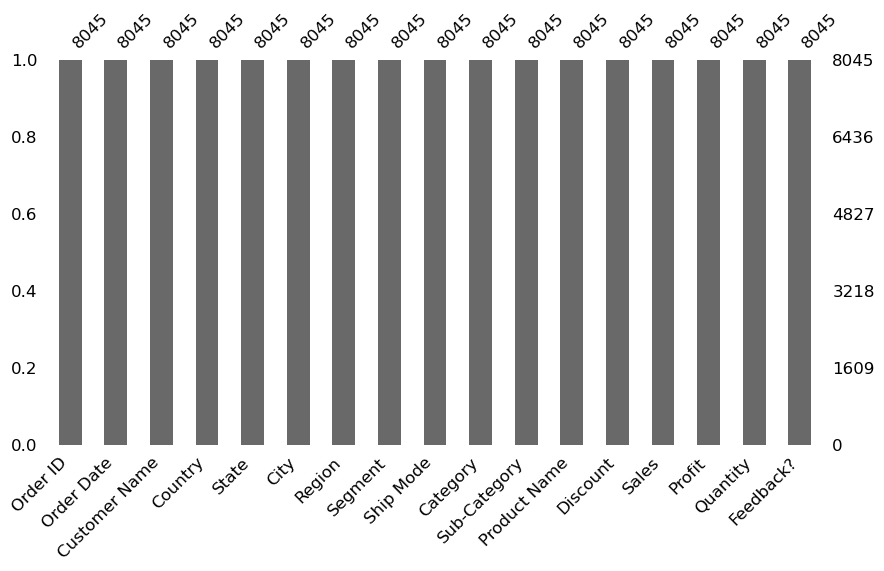

In [16]:
mn.bar(df, figsize=(10, 5), fontsize=12)

In [17]:
df.dtypes

Order ID                 object
Order Date       datetime64[ns]
Customer Name            object
Country                  object
State                    object
City                     object
Region                   object
Segment                  object
Ship Mode                object
Category                 object
Sub-Category             object
Product Name             object
Discount                float64
Sales                     int64
Profit                    int64
Quantity                  int64
Feedback?                  bool
dtype: object

Extract column order date into year, month, day, day name, and month name

In [18]:
# Membuat kolom 'Tahun' dari kolom 'Order Date'
df['Year'] = df['Order Date'].dt.year

# Membuat kolom 'Bulan' (format numerik, 1 - 12)
df['Month'] = df['Order Date'].dt.month

# Membuat kolom 'Hari'
df['Day'] = df['Order Date'].dt.day

# Membuat kolom 'NamaHari' (contoh: Monday, Tuesday, dsb.)
df['DayNames'] = df['Order Date'].dt.day_name()

# Misal membuat kolom 'MonthYear' (dalam format 'Jan-2021')
df['MonthYear'] = df['Order Date'].dt.strftime('%b-%Y')


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8045 entries, 0 to 8044
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       8045 non-null   object        
 1   Order Date     8045 non-null   datetime64[ns]
 2   Customer Name  8045 non-null   object        
 3   Country        8045 non-null   object        
 4   State          8045 non-null   object        
 5   City           8045 non-null   object        
 6   Region         8045 non-null   object        
 7   Segment        8045 non-null   object        
 8   Ship Mode      8045 non-null   object        
 9   Category       8045 non-null   object        
 10  Sub-Category   8045 non-null   object        
 11  Product Name   8045 non-null   object        
 12  Discount       8045 non-null   float64       
 13  Sales          8045 non-null   int64         
 14  Profit         8045 non-null   int64         
 15  Quantity       8045 n

In [20]:
df.describe()

,Order Date,Discount,Sales,Profit,Quantity,Year,Month,Day
count,8045,8045.000000,8045.000000,8045.000000,8045.000000,8045.000000,8045.000000,8045.000000
mean,2013-04-19 12:57:32.778123008,0.110075,291.903170,35.202237,3.772281,2012.728900,7.365320,15.823120
min,2011-01-01 00:00:00,0.000000,3.000000,-3060.000000,1.000000,2011.000000,1.000000,1.000000
25%,2012-06-08 00:00:00,0.000000,48.000000,1.000000,2.000000,2012.000000,5.000000,8.000000
50%,2013-06-11 00:00:00,0.000000,117.000000,14.000000,3.000000,2013.000000,8.000000,16.000000
75%,2014-04-30 00:00:00,0.100000,313.000000,47.000000,5.000000,2014.000000,10.000000,24.000000
max,2014-12-31 00:00:00,0.850000,6517.000000,2476.000000,14.000000,2014.000000,12.000000,31.000000
std,NaN,0.181787,485.258616,178.147747,2.203610,1.100367,3.321856,8.735272


Checking data values with negative values

In [21]:
negative_values = df[df['Profit'] < 0]
negative_values

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?,Year,Month,Day,DayNames,MonthYear
0,BN-2011-7407039,2011-01-01,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,Paper,"Enermax Note Cards, Premium",0.50,45,-26,3,False,2011,1,1,Saturday,Jan-2011
3,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Art,"Boston Markers, Easy-Erase",0.50,27,-22,2,True,2011,1,4,Tuesday,Jan-2011
4,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Storage,"Eldon Folders, Single Width",0.50,17,-1,2,True,2011,1,4,Tuesday,Jan-2011
10,BN-2011-3248724,2011-01-08,Archer Hort,France,Languedoc-Roussillon-Midi-Pyrénées,Toulouse,Central,Consumer,Economy,Furniture,Bookcases,"Ikea Classic Bookcase, Metal",0.60,987,-1012,6,True,2011,1,8,Saturday,Jan-2011
11,BN-2011-3248724,2011-01-08,Archer Hort,France,Languedoc-Roussillon-Midi-Pyrénées,Toulouse,Central,Consumer,Economy,Office Supplies,Art,"Binney & Smith Sketch Pad, Blue",0.50,116,-56,5,False,2011,1,8,Saturday,Jan-2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8024,AZ-2014-8026360,2014-12-29,Darcy Farnell,France,Ile-de-France,Sarcelles,Central,Consumer,Economy,Technology,Machines,"Epson Inkjet, Wireless",0.15,524,-25,2,False,2014,12,29,Monday,Dec-2014
8027,BN-2014-8679573,2014-12-30,Dennis Conaway,Netherlands,South Holland,The Hague,Central,Consumer,Priority,Office Supplies,Appliances,"Cuisinart Blender, Silver",0.50,68,-62,2,False,2014,12,30,Tuesday,Dec-2014
8041,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Art,"BIC Pencil Sharpener, Fluorescent",0.50,30,-10,2,False,2014,12,31,Wednesday,Dec-2014
8042,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Binders,"Avery Binder Covers, Recycled",0.50,23,-6,4,True,2014,12,31,Wednesday,Dec-2014


# Data Analysis
---

Checking Time Scope Periode 

In [22]:
df['Order Date'].agg(['min', 'max'])

min   2011-01-01
max   2014-12-31
Name: Order Date, dtype: datetime64[ns]

This Dataset contains 4 years of record sales;
- 2011
- 2012
- 2013
- 2014

### 1. Costumer Performance Analysis
---

Identify top costumers based on Total Sales by grouping and aggregation total orders, total sales, total quantity, and total profit

Top 10 Customers by Total Sales:
        Customer Name  Total Orders  Total Sales  Total Quantity  Total Profit
49   Angie Massengill            10        16146             102          4932
499       Lola Hughes             9        13191             127          2242
70     Ashton Charles            10        13056              63          3780
316       Isaac David            10        11271             110          1836
633     Philip Newsom            10        10893              80          1204
379       Joel Peters             6        10477             137          1213
90        Bettie Lang             6        10466             108         -1698
75     Audrey Knowles             9        10363              96          -287
486    Lilly Le Grand            11         9962              88          1239
206    Elijah Sodeman            10         9689             101          2752


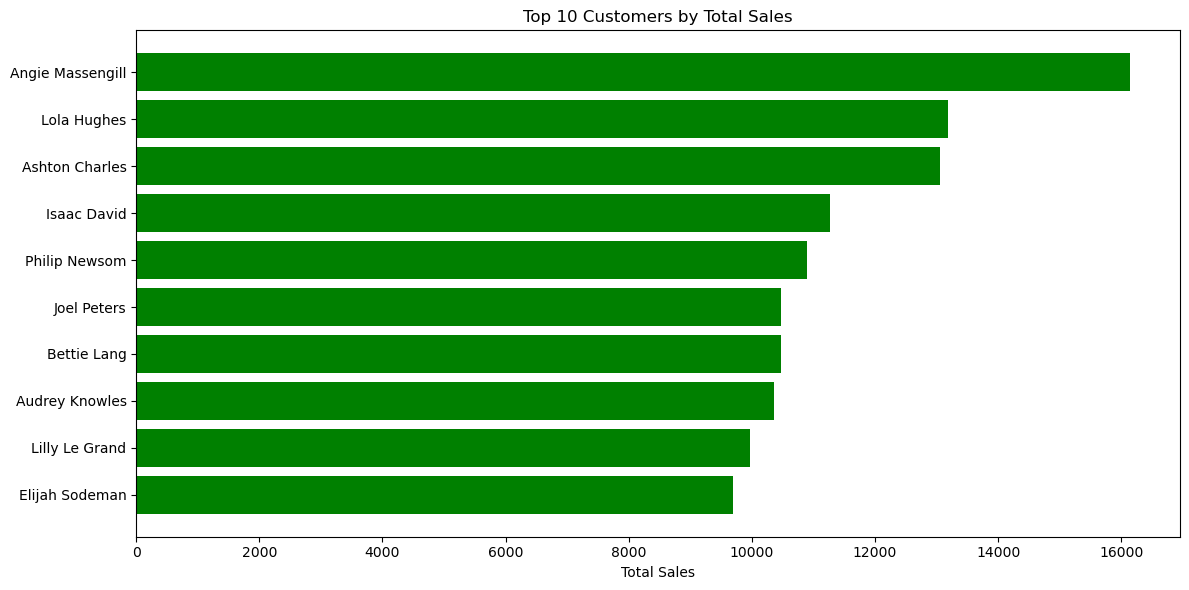

In [23]:
# Group by Customer Name untuk menghitung total order, total sales, quantity, dan profit
customer_analysis = df.groupby("Customer Name").agg({
    "Order ID": pd.Series.nunique,
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).reset_index()

# Rename kolom agar lebih jelas
customer_analysis.columns = ["Customer Name", "Total Orders", "Total Sales", "Total Quantity", "Total Profit"]

# Urutkan berdasarkan Total Sales terbesar
top_customers = customer_analysis.sort_values(by="Total Sales", ascending=False).head(10)

# Tampilkan hasil
print("Top 10 Customers by Total Sales:")
print(top_customers)

# Visualisasi (Optional)
plt.figure(figsize=(12, 6))
plt.barh(top_customers["Customer Name"], top_customers["Total Sales"], color="Green")
plt.xlabel("Total Sales")
plt.title("Top 10 Customers by Total Sales")
plt.gca().invert_yaxis()  # Agar yang tertinggi ada di atas
plt.tight_layout()
plt.show()

### Insight :
- Angie Massengill is the top customer in terms of total sales, contributing over 16,000 in sales value.
- Other high-value customers include Lola Hughes and Ashton Charles, rounding out the top 3.
- These individuals can be classified as high-value customers, playing a significant role in overall business revenue.

- This insight is essential for:
    - Designing customer-centric marketing strategies.
    - Offering exclusive services or loyalty programs to top-tier customers.
    - Maximizing profitability through customer retention and engagement.

### 2. Top Costumer Profitability Analysis
---
based on total profit

Top 10 Customers by Total Profit:
        Customer Name  Total Orders  Total Sales  Total Quantity  Total Profit
49   Angie Massengill            10        16146             102          4932
70     Ashton Charles            10        13056              63          3780
263     George Dawson             5         8506              45          2944
23     Alexander Bond             4         7927              35          2899
286    Harrison Cooke             3         8701              25          2889
206    Elijah Sodeman            10         9689             101          2752
642     Rachel Norton             5         7376              46          2729
453       Lara Stoate             8         6732              44          2658
95    Bianca Whitford             8         9259              60          2529
552   Maya O'Sullivan             8         7215              53          2418


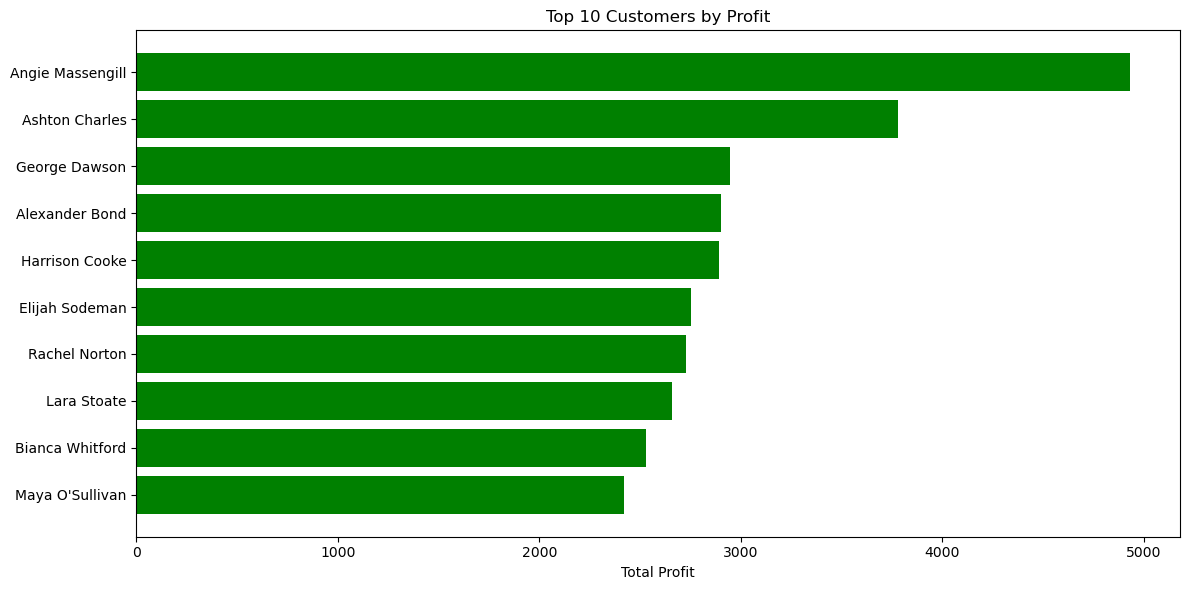

In [24]:
# Group by Customer Name dan hitung metrik
customer_analysis = df.groupby("Customer Name").agg({
    "Order ID": pd.Series.nunique,
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).reset_index()

# Rename kolom
customer_analysis.columns = ["Customer Name", "Total Orders", "Total Sales", "Total Quantity", "Total Profit"]

# Ambil 10 pelanggan dengan profit tertinggi
top_profit = customer_analysis.sort_values(by="Total Profit", ascending=False).head(10)

# Tampilkan data
print("Top 10 Customers by Total Profit:")
print(top_profit)

# Visualisasi (opsional)
plt.figure(figsize=(12, 6))
plt.barh(top_profit["Customer Name"], top_profit["Total Profit"], color="green")
plt.xlabel("Total Profit")
plt.title("Top 10 Customers by Profit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Insight:

- Angie Massengill is the most profitable customer, contributing nearly $5,000 in profit.
- Ashton Charles and George Dawson follow as the second and third most profitable customers.
- There are noticeable differences between the Top 10 by Sales and Top 10 by Profit, indicating that high sales don’t always mean high profit.

- This analysis is crucial for:
    - Identifying customers who bring the most profit, not just the highest revenue.
    - Prioritizing high-margin clients for targeted offers and premium services.
    - Refining strategies for customer segmentation and profit optimization.

### 3. Costumer Segmentation Analysis
---
based on Segment, Region, and Feedback with the following metrics is aggregated: order id, sales, profit, quantity

Customer Segmentation Analysis:
        Segment   Region  Feedback Given  Total Orders  Total Sales  \
0      Consumer  Central           False           788       362419   
1      Consumer  Central            True           772       339436   
2      Consumer    North           False           334       134113   
3      Consumer    North            True           320       133842   
4      Consumer    South           False           307       129822   
5      Consumer    South            True           308       136613   
6     Corporate  Central           False           448       197154   
7     Corporate  Central            True           447       199283   
8     Corporate    North           False           185        69348   
9     Corporate    North            True           199        94643   
10    Corporate    South           False           208        96123   
11    Corporate    South            True           195        81586   
12  Home Office  Central           False     

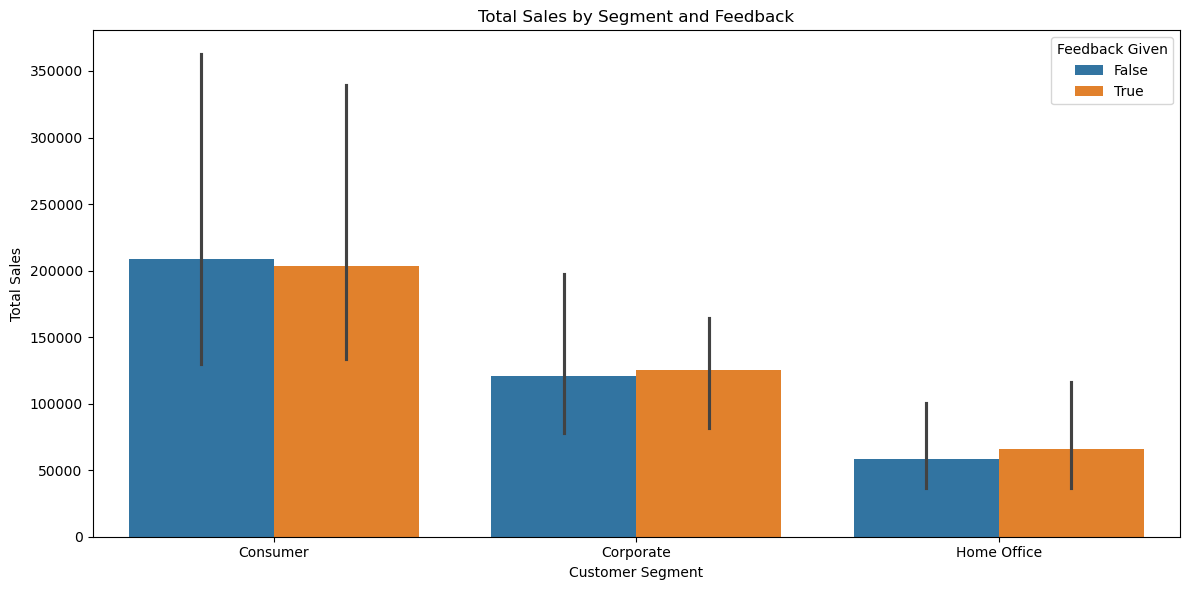

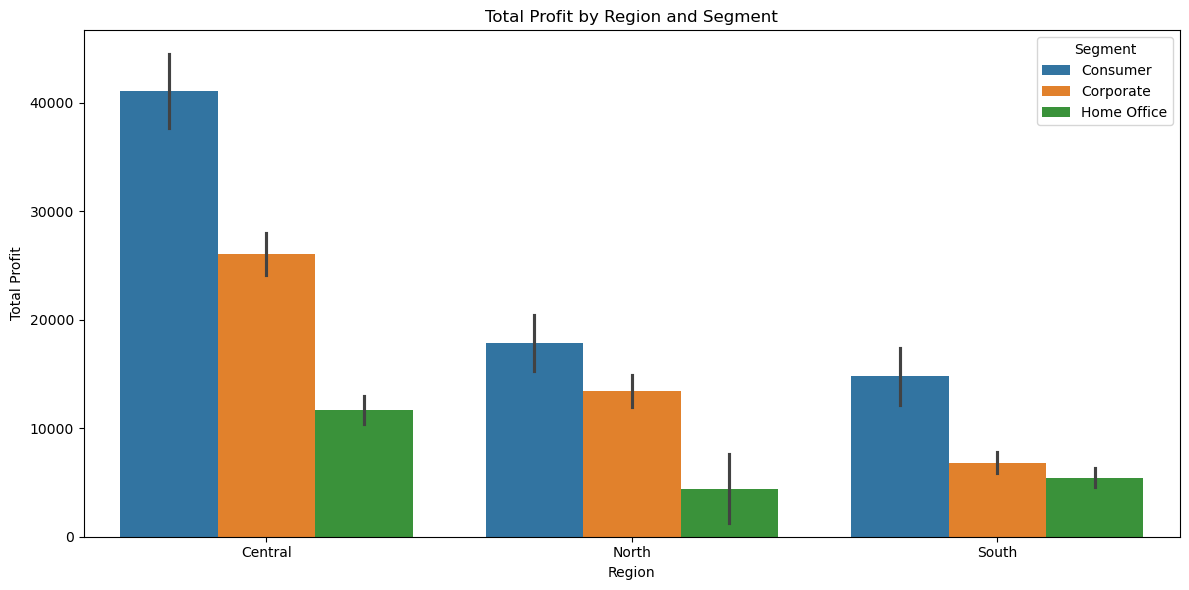

In [25]:
# Group by Segment, Region, and Feedback
segmentation = df.groupby(["Segment", "Region", "Feedback?"]).agg({
    "Order ID": pd.Series.nunique,
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
}).reset_index()

# Rename kolom
segmentation.columns = ["Segment", "Region", "Feedback Given", "Total Orders", "Total Sales", "Total Profit", "Total Quantity"]

# Tampilkan data
print("Customer Segmentation Analysis:")
print(segmentation)

# Visualisasi: Bar plot untuk Total Sales
plt.figure(figsize=(12, 6))
sns.barplot(data=segmentation, x="Segment", y="Total Sales", hue="Feedback Given")
plt.title("Total Sales by Segment and Feedback")
plt.ylabel("Total Sales")
plt.xlabel("Customer Segment")
plt.tight_layout()
plt.show()

# Visualisasi: Bar plot untuk Total Profit
plt.figure(figsize=(12, 6))
sns.barplot(data=segmentation, x="Region", y="Total Profit", hue="Segment")
plt.title("Total Profit by Region and Segment")
plt.ylabel("Total Profit")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

### Insight:

 Chart 1: Total Sales by Segment and Feedback
- Consumer segment generates the highest sales overall, regardless of feedback.

- There’s no significant difference in total sales between customers who provided feedback (True) and those who did not (False).

- This may indicate that sales volume is not strongly driven by customer feedback behavior, at least in terms of aggregate totals.

 Chart 2: Total Profit by Region and Segment
- The Central region contributes the highest profit, especially from the Consumer segment.

- In all regions (Central, North, South), Consumer segment leads in profitability, followed by Corporate, then Home Office.

- The Home Office segment consistently shows the lowest profit, signaling it may be a less profitable market to focus on or may need different strategies (e.g., pricing, targeting).

### 4. Correlation Customer Segment and Region
---
based on Total sales and Total Profit

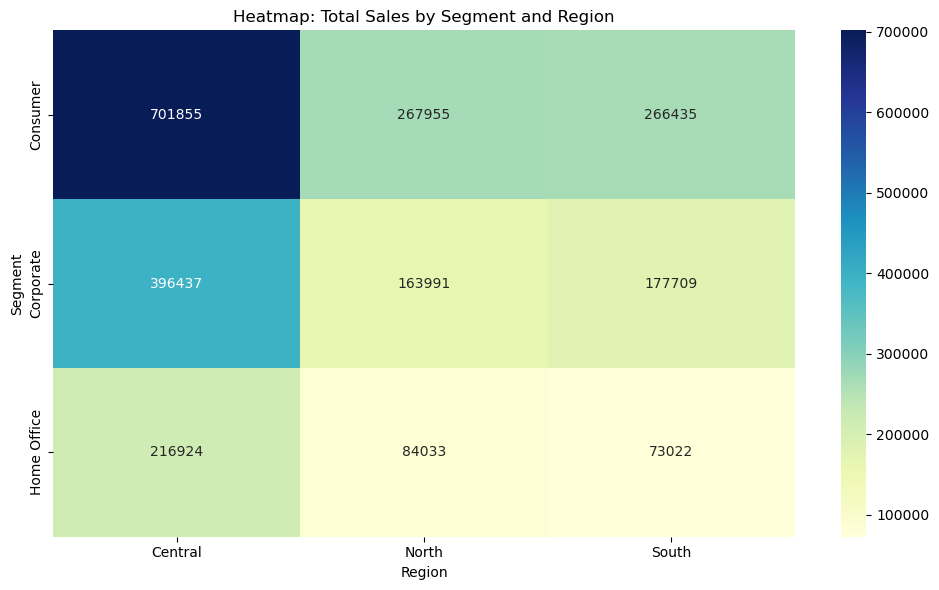

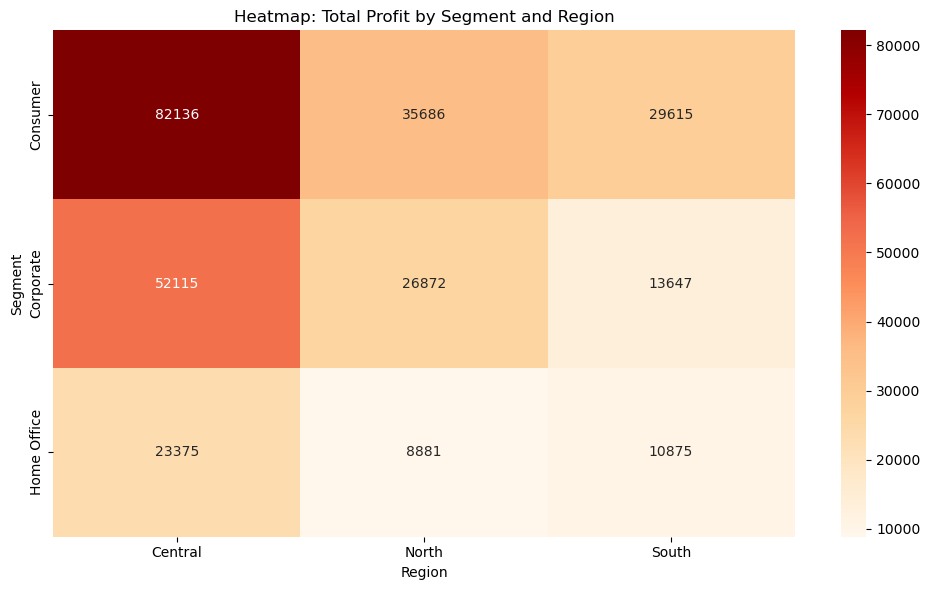

In [26]:
# Pivot data untuk heatmap: Total Sales
sales_pivot = segmentation.pivot_table(values="Total Sales", index="Segment", columns="Region", aggfunc="sum")

plt.figure(figsize=(10, 6))
sns.heatmap(sales_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap: Total Sales by Segment and Region")
plt.ylabel("Segment")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

# Pivot data untuk heatmap: Total Profit
profit_pivot = segmentation.pivot_table(values="Total Profit", index="Segment", columns="Region", aggfunc="sum")

plt.figure(figsize=(10, 6))
sns.heatmap(profit_pivot, annot=True, fmt=".0f", cmap="OrRd")
plt.title("Heatmap: Total Profit by Segment and Region")
plt.ylabel("Segment")
plt.xlabel("Region")
plt.tight_layout()
plt.show()


### Heatmap 1: Total Sales by Segment and Region
---
- The Consumer segment in the Central region shows the highest total sales, with over 701,000 units.

- Sales for the Corporate segment follow, particularly strong in the Central region.

- The Home Office segment consistently reports lower sales across all regions, especially in the North and South.

- The Central region is a dominant driver of sales across all segments.

*Interpretation:*
- Central region + Consumer segment is a key sales driver.

- Home Office customers in the North and South may need attention or better-targeted marketing to increase sales.

### Heatmap 2: Total Profit by Segment and Region
---

*Insights:*
- Again, the Consumer segment in the Central region leads in profitability (~82,000).

- The Corporate segment follows, though with significantly lower profit, especially in the South region.

- The Home Office segment shows very low profit across all regions, with North region profitability the lowest (~8,800).

*Interpretation:*
- Profitability aligns with sales patterns, but profit margins are visibly weaker in the Home Office segment.

- The Central region is not just high in sales, but also strongly profitable—a clear growth opportunity.

### 5. Location Based Sales Analysis
---
based on country, state, city over total sales and total profit

Top 15 Locations by Total Sales:
            Country                       State       City  Sales  Profit
922  United Kingdom                     England     London  69230   13931
425         Germany                      Berlin     Berlin  52555    5942
7           Austria                      Vienna     Vienna  51844   13207
806           Spain                      Madrid     Madrid  44897   11101
233          France               Ile-de-France      Paris  42245    6680
606           Italy                       Lazio       Rome  28330     191
782           Spain                   Catalonia  Barcelona  27405    2246
432         Germany                     Hamburg    Hamburg  23574    5858
379          France  Provence-Alpes-Côte d'Azur  Marseille  21677    2889
636           Italy                    Piedmont      Turin  19829    1937
621           Italy                    Lombardy      Milan  18837     233
420         Germany                     Bavaria     Munich  18429    3463
990  

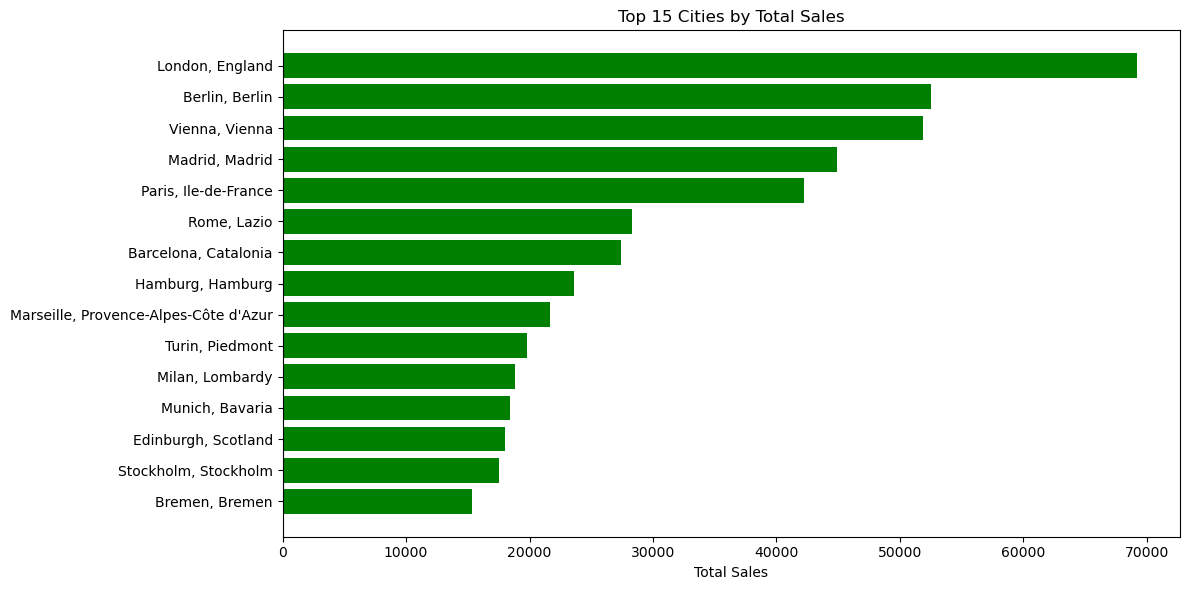

In [27]:
# Group by Country, State, City untuk menghitung total sales dan profit
location_sales = df.groupby(["Country", "State", "City"]).agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

# Ambil 15 lokasi teratas berdasarkan total sales
top_locations = location_sales.sort_values(by="Sales", ascending=False).head(15)

# Tampilkan hasil
print("Top 15 Locations by Total Sales:")
print(top_locations)

# Buat kolom gabungan untuk label lokasi
top_locations["Location"] = top_locations["City"] + ", " + top_locations["State"]

# Visualisasi
plt.figure(figsize=(12, 6))
plt.barh(top_locations["Location"], top_locations["Sales"], color="green")
plt.xlabel("Total Sales")
plt.title("Top 15 Cities by Total Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

*Insight:*
- London, England stands out as the top-performing city in terms of sales, with nearly 70,000 in total revenue.
- Other strong performers include:
    - Berlin, Germany
    - Vienna, Austria
    - Madrid, Spain
    - Paris, France

- These top cities are major urban centers, which typically:

- Have higher population densities.

- Host a large number of business clients and consumers.

- Represent stronger economic regions.

- Cities like Bremen, Stockholm, and Edinburgh also appear in the top 15 but with noticeably lower sales than the top 5.



### 6. Geographic Sales Analysis
---
Calculates total sales and profit for each major region (central, north, south) and individual state

Sales by Region:
    Region    Sales  Profit
0  Central  1315216  157626
1    North   515979   71439
2    South   517166   54137

Top 10 States by Sales:
                           State   Sales  Profit
41                       England  378984   79069
59                 Ile-de-France  230138   29457
81        North Rhine-Westphalia  170233   32572
87    Provence-Alpes-Côte d'Azur   81524   11615
70                        Madrid   57123   13245
7           Auvergne-Rhône-Alpes   55572    9283
15                        Berlin   52555    5942
77   Nord-Pas-de-Calais-Picardie   52007    5207
119                       Vienna   51844   13207
14                       Bavaria   49103    9490


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\3451474038.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x="Region", y="Sales", palette="Blues_d")


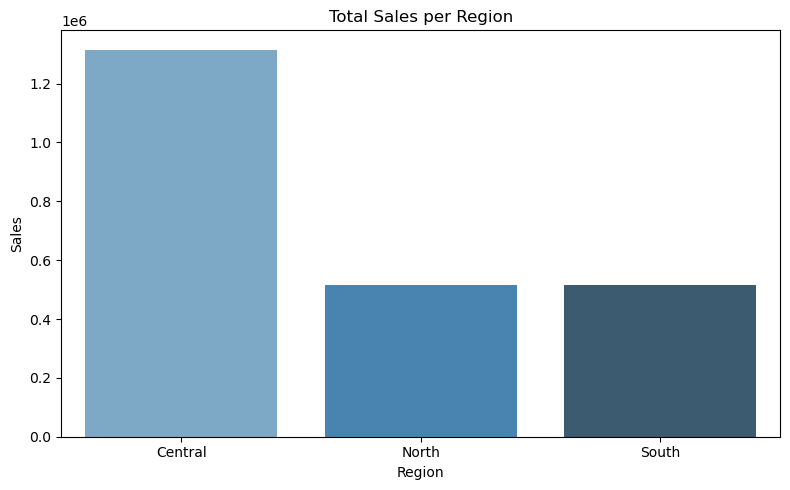

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\3451474038.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales.head(10), x="Sales", y="State", palette="Greens_d")


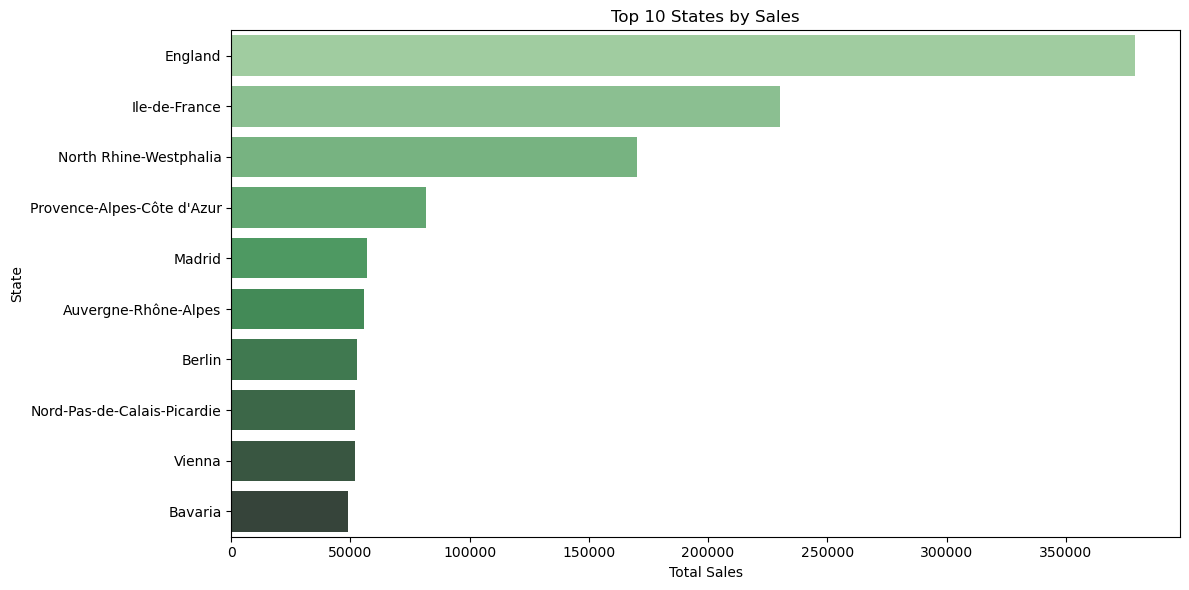

In [28]:
# Group by Region
region_sales = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

# Group by State
state_sales = df.groupby("State").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index().sort_values(by="Sales", ascending=False)

# Tampilkan hasil Region
print("Sales by Region:")
print(region_sales)

# Tampilkan hasil State (Top 10)
print("\nTop 10 States by Sales:")
print(state_sales.head(10))

# Visualisasi: Bar chart per Region
plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x="Region", y="Sales", palette="Blues_d")
plt.title("Total Sales per Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

# Visualisasi: Bar chart Top 10 States
plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales.head(10), x="Sales", y="State", palette="Greens_d")
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Chart 1: Total Sales per Region
- The Central region dominates with sales exceeding 1.3 million, far surpassing both the North and South.
- The North and South regions perform similarly, but at less than half the Central region’s sales volume.

### Chart 2: Top 10 States by Sales
- England is the top-performing state with the highest sales.

- Other strong performers include:

    - Île-de-France (France)

    - North Rhine-Westphalia (Germany)

    - Provence-Alpes-Côte d'Azur, Madrid, Auvergne-Rhône-Alpes, and Berlin

- The majority of top states are located in Western Europe, particularly from the UK, France, Germany, and Spain.



### 7. Products Analysis
---
based on quantity sold and total sales

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\2001959063.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_by_quantity, x="Quantity", y="Product Name", palette="Blues_d")


Top 10 Products by Quantity:
                               Product Name  Quantity  Sales  Profit
1367         Rogers File Cart, Single Width       108  12967    1312
582           Eldon File Cart, Single Width       104  11233    2539
293         Binney & Smith Sketch Pad, Blue        90   3578     487
1645  Stanley Pencil Sharpener, Water Color        89   2035    -178
183                  Avery Index Tab, Clear        81    467      67
311    Boston Pencil Sharpener, Water Color        80   2109     563
1732          Tenex File Cart, Single Width        78   8817    1576
1529           Sanford Markers, Water Color        75   1946     143
299              Boston Canvas, Fluorescent        73   3599     310
993                  Ibico Index Tab, Clear        72    586     104

Top 10 Products by Sales:
                                           Product Name  Quantity  Sales  \
1223                       Nokia Smart Phone, Full Size        54  30645   
832                        Hamilt

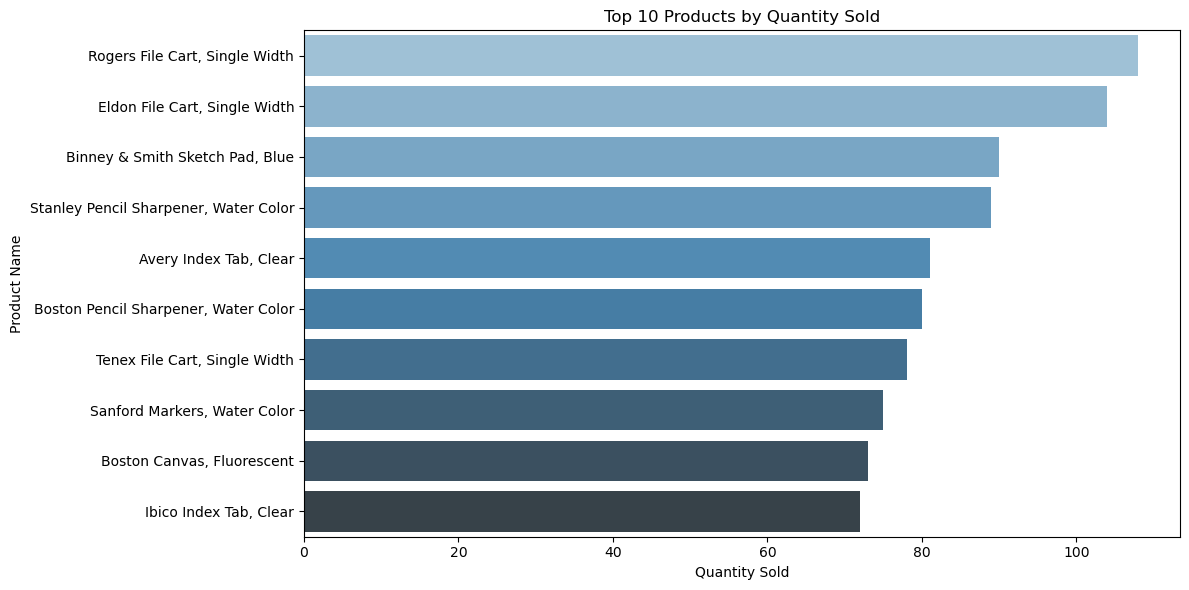

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\2001959063.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_by_sales, x="Sales", y="Product Name", palette="Greens_d")


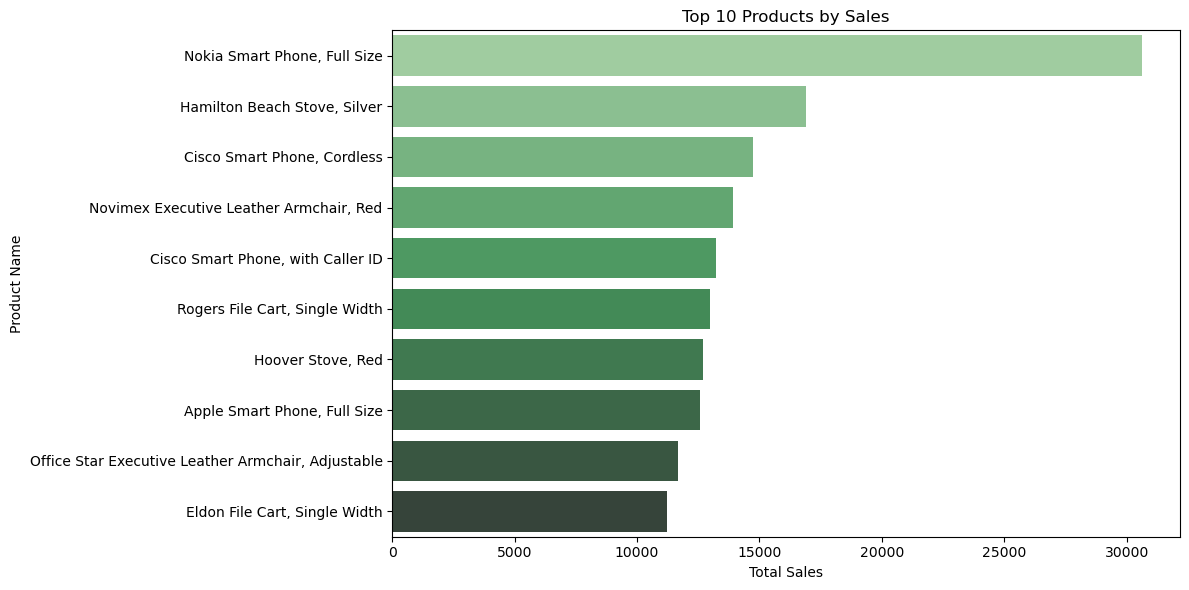

In [29]:
# Group by Product Name untuk menghitung total Quantity, Sales, dan Profit
top_products = df.groupby("Product Name").agg({
    "Quantity": "sum",
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

# Top 10 produk berdasarkan Quantity
top_by_quantity = top_products.sort_values(by="Quantity", ascending=False).head(10)

# Top 10 produk berdasarkan Sales
top_by_sales = top_products.sort_values(by="Sales", ascending=False).head(10)

# Tampilkan hasil di terminal
print("Top 10 Products by Quantity:")
print(top_by_quantity)
print("\nTop 10 Products by Sales:")
print(top_by_sales)

# Visualisasi: Top 10 by Quantity
plt.figure(figsize=(12, 6))
sns.barplot(data=top_by_quantity, x="Quantity", y="Product Name", palette="Blues_d")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

# Visualisasi: Top 10 by Sales
plt.figure(figsize=(12, 6))
sns.barplot(data=top_by_sales, x="Sales", y="Product Name", palette="Greens_d")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

### Chart 1: Top 10 Products by Quantity Sold
- "Rogers File Cart, Single Width" and "Eldon File Cart, Single Width" are the most frequently sold products (by volume).

- Many of the top products are low-priced office supplies, such as:
    - Sketch pads

    - Pencil sharpeners

    - Index tabs

- These products are likely fast-moving, low-margin items that are bought in bulk.

### Chart 2: Top 10 Products by Sales
- "Nokia Smart Phone, Full Size" is the top product by total sales, followed by smart home appliances like:
    - "Hamilton Beach Stove"
    - "Cisco Smart Phone"
- High-value items (phones, furniture, stoves) dominate the top sales chart, even though they may sell in lower quantities.

Profitability analysis per product

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\1517366666.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_by_profit, x="Profit", y="Product Name", palette="OrRd")


Top 10 Products by Profit:
                                 Product Name  Quantity  Sales  Profit
1223             Nokia Smart Phone, Full Size        54  30645    7583
966                         Hoover Stove, Red        23  12677    6139
832              Hamilton Beach Stove, Silver        33  16890    5778
1416  SAFCO Executive Leather Armchair, Black        26  10649    4324
1433            Safco Classic Bookcase, Metal        22   9190    4183
477         Cisco Smart Phone, with Caller ID        25  13215    4055
345                Brother Fax Machine, Laser        30   9557    3918
595                 Eldon Lockers, Industrial        49   8572    3611
475               Cisco Smart Phone, Cordless        29  14723    3388
831                 Hamilton Beach Stove, Red        13   6616    2738


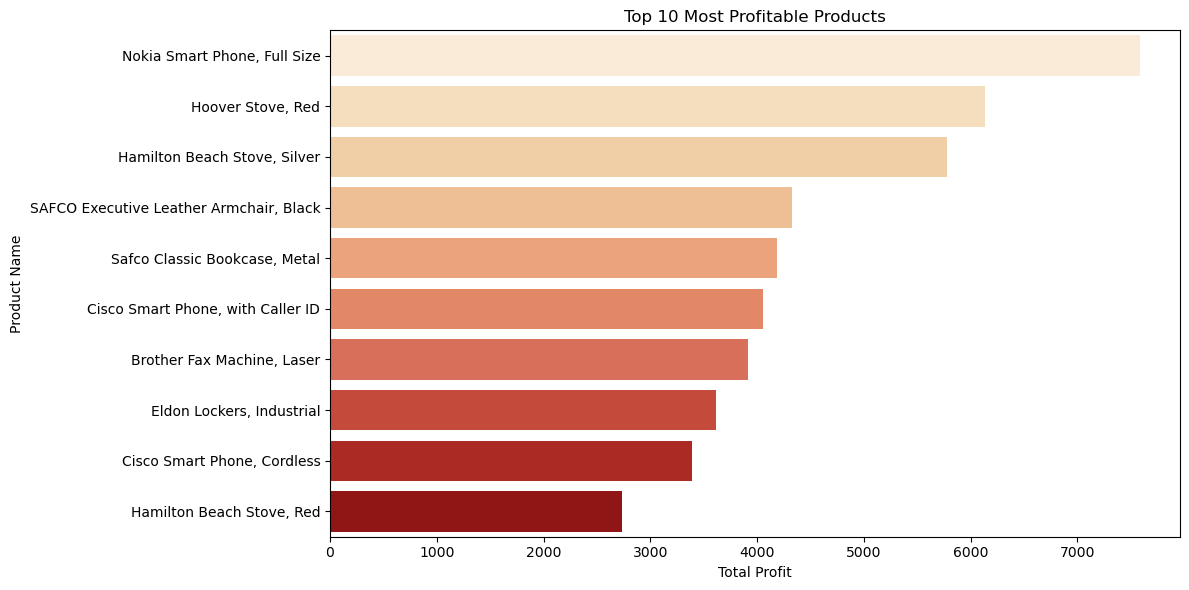

In [30]:
# Group by Product Name untuk menghitung total Quantity, Sales, dan Profit
top_products = df.groupby("Product Name").agg({
    "Quantity": "sum",
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

# Top 10 produk paling menguntungkan berdasarkan Profit
top_by_profit = top_products.sort_values(by="Profit", ascending=False).head(10)

# Tampilkan hasil di terminal
print("Top 10 Products by Profit:")
print(top_by_profit)

# Visualisasi: Top 10 by Profit
plt.figure(figsize=(12, 6))
sns.barplot(data=top_by_profit, x="Profit", y="Product Name", palette="OrRd")
plt.title("Top 10 Most Profitable Products")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

*insight:*
- Top Profitable Products:
    - Nokia Smart Phone, Full Size is the most profitable product, generating a profit of over 7,500.
    - High-profit items also include:
    - Hoover Stove, Red
    - Hamilton Beach Stove, Silver
    - SAFCO Executive Leather Armchair
    - Cisco Smart Phones

- These are high-value, high-margin products that may not be the most sold by quantity, but yield significant profits per unit.

Aggregated performance analysis

Rata-rata Diskon, Sales, dan Profit per Kategori dan Sub-Kategori:
           Category Sub-Category  Avg Discount    Avg Sales  Avg Profit
0         Furniture    Bookcases      0.116113   752.930946  111.649616
1         Furniture       Chairs      0.203394   487.462141   40.441253
2         Furniture  Furnishings      0.105141   175.416452   29.102828
3         Furniture       Tables      0.369333  1193.040000 -276.413333
4   Office Supplies   Appliances      0.119574   893.191489  161.302128
5   Office Supplies          Art      0.072459   110.466551   20.400521
6   Office Supplies      Binders      0.070416    74.527410   13.870510
7   Office Supplies    Envelopes      0.071676    90.202312   18.679191
8   Office Supplies    Fasteners      0.103429    46.394286    9.771429
9   Office Supplies       Labels      0.066667    34.467742    7.086022
10  Office Supplies        Paper      0.071390    96.409091   20.013369
11  Office Supplies      Storage      0.172502   259.266413   20.9276

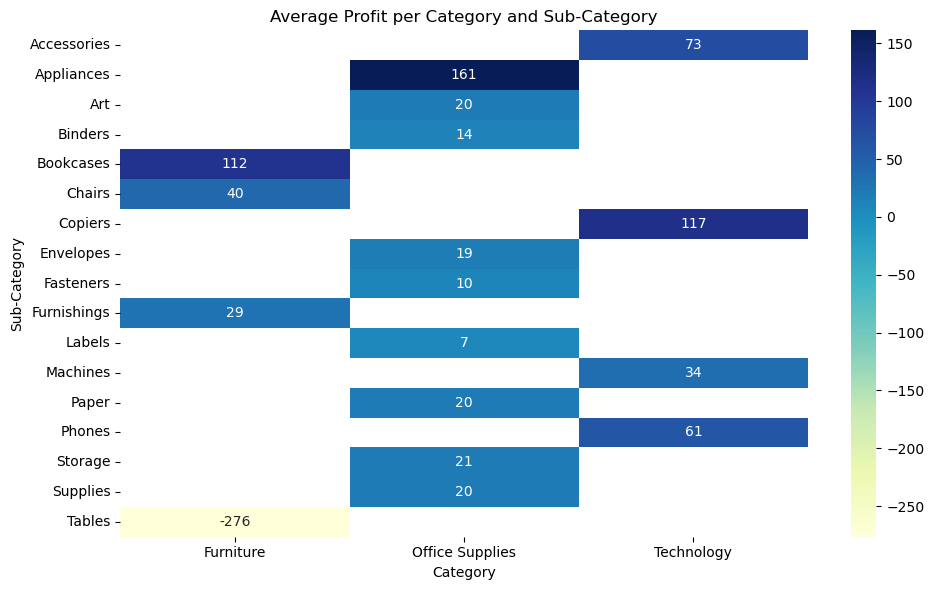

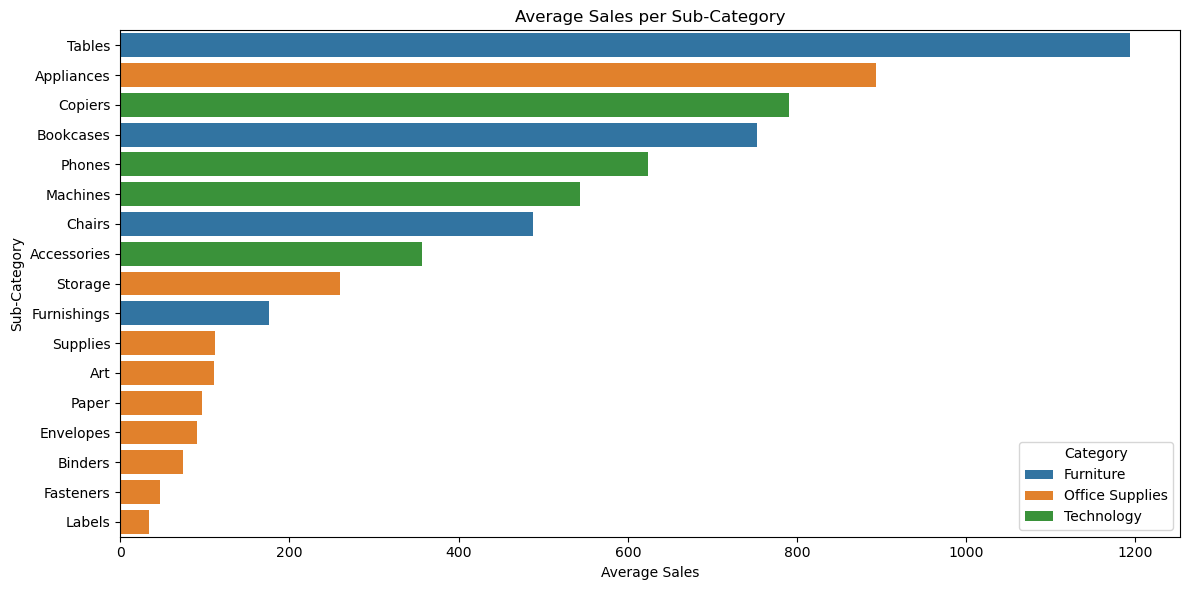

In [31]:
# Group by Category dan Sub-Category untuk menghitung rata-rata
category_analysis = df.groupby(["Category", "Sub-Category"]).agg({
    "Discount": "mean",
    "Sales": "mean",
    "Profit": "mean"
}).reset_index()

# Rename kolom
category_analysis.columns = ["Category", "Sub-Category", "Avg Discount", "Avg Sales", "Avg Profit"]

# Tampilkan hasil
print("Rata-rata Diskon, Sales, dan Profit per Kategori dan Sub-Kategori:")
print(category_analysis)

# Visualisasi Heatmap: Rata-rata Profit
pivot_profit = category_analysis.pivot(index="Sub-Category", columns="Category", values="Avg Profit")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Profit per Category and Sub-Category")
plt.tight_layout()
plt.show()

# Visualisasi Bar Chart: Rata-rata Sales
plt.figure(figsize=(12, 6))
sns.barplot(data=category_analysis.sort_values("Avg Sales", ascending=False),
            x="Avg Sales", y="Sub-Category", hue="Category")
plt.title("Average Sales per Sub-Category")
plt.xlabel("Average Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

*Insight:*
### 1. Heatmap: Average Profit per Category & Sub-Category
Key Observations:
- Appliances (Office Supplies), Copiers (Technology), and Bookcases (Furniture) show the highest average profit among their categories.
- Tables (Furniture) have a strong negative average profit (-276), despite high sales, indicating a loss-making product.
- Sub-categories like Labels, Fasteners, and Binders have very low profit margins, which may not justify heavy inventory investment.

### 2. Bar Chart: Average Sales per Sub-Category
Key Observations:
- Tables have the highest average sales, followed by Appliances and Copiers, making them top revenue generators.
- Despite high sales, Tables have negative profit, indicating high costs or discounting issues.
- Sub-categories like Art, Paper, Binders, and Fasteners show lower average sales, possibly being low-ticket and high-frequency items.

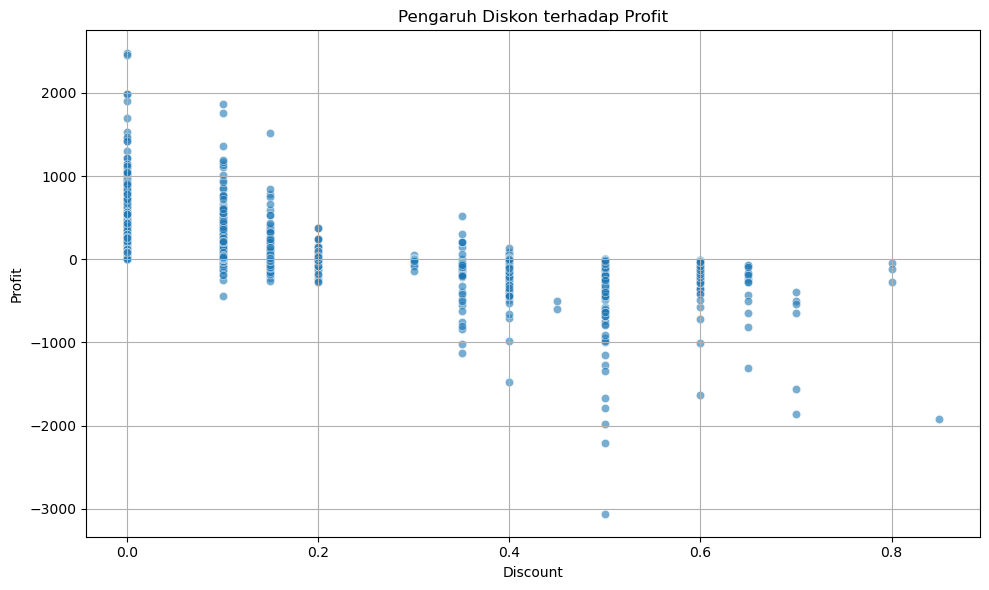

Korelasi antara Diskon dan Profit: -0.35
Diskon tinggi cenderung menurunkan profit.


In [32]:
# Scatter plot: Discount vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.6)
plt.title("Pengaruh Diskon terhadap Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

# Hitung korelasi
correlation = df[["Discount", "Profit"]].corr().iloc[0, 1]
print(f"Korelasi antara Diskon dan Profit: {correlation:.2f}")

# Interpretasi
if correlation < 0:
    print("Diskon tinggi cenderung menurunkan profit.")
elif correlation > 0:
    print("Diskon tinggi cenderung meningkatkan profit.")
else:
    print("Tidak ada hubungan antara diskon dan profit.")

### 8. Operational Analysis
---

performance analysis of shipping modes by calculating and visualizing the average sales, profit, quantity, and discount for each Ship Mode

Efisiensi Performa Ship Mode:
      Ship Mode   Avg Sales  Avg Profit  Avg Quantity  Avg Discount
0       Economy  290.669959   36.760905      3.782716      0.109259
1  Economy Plus  304.380503   34.173585      3.773585      0.111289
2     Immediate  308.248826   41.241784      3.659624      0.090258
3      Priority  274.102652   27.920445      3.768178      0.119033


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\960252729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipmode_efficiency, x="Ship Mode", y="Avg Profit", palette="YlGn")


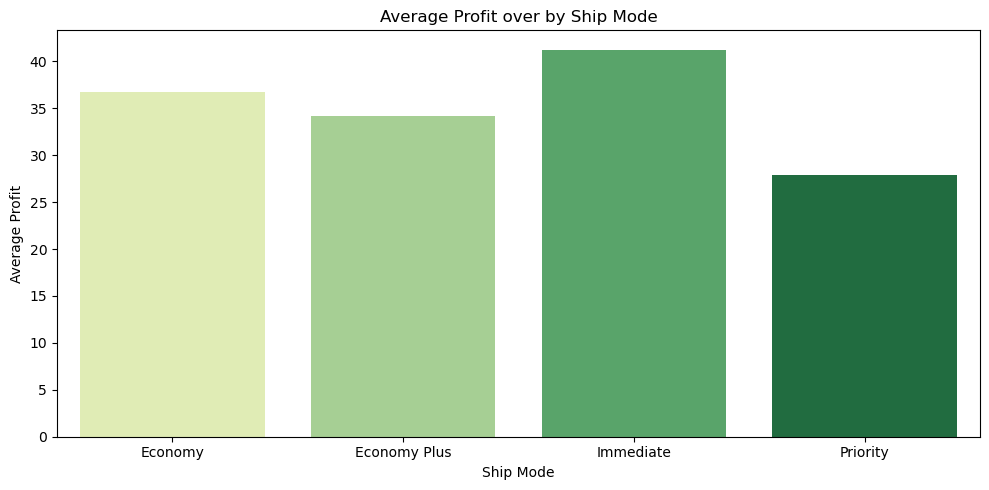

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\960252729.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipmode_efficiency, x="Ship Mode", y="Avg Discount", palette="OrRd")


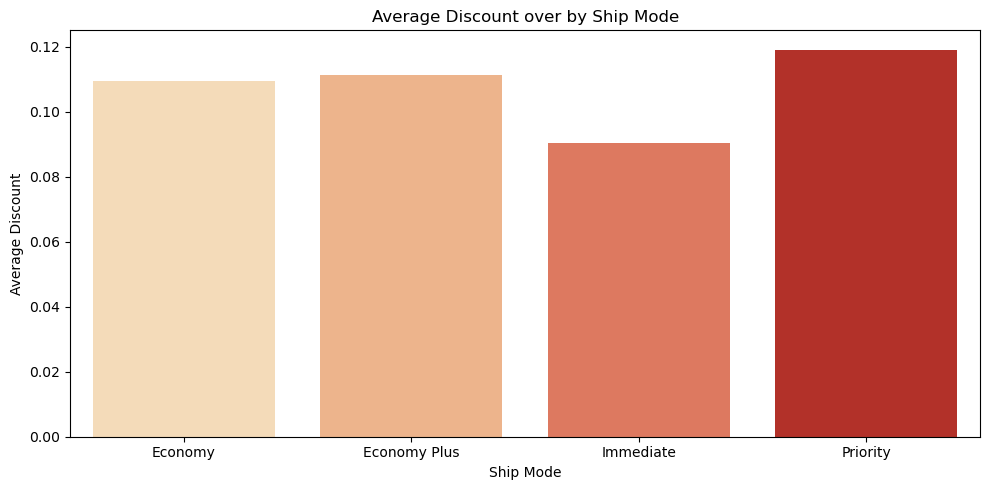

In [33]:
# Group by Ship Mode dan hitung rata-rata
shipmode_efficiency = df.groupby("Ship Mode").agg({
    "Sales": "mean",
    "Profit": "mean",
    "Quantity": "mean",
    "Discount": "mean"
}).reset_index()

# Rename kolom agar lebih jelas
shipmode_efficiency.columns = ["Ship Mode", "Avg Sales", "Avg Profit", "Avg Quantity", "Avg Discount"]

# Tampilkan hasil
print("Efisiensi Performa Ship Mode:")
print(shipmode_efficiency)

# Visualisasi: Avg Profit per Ship Mode
plt.figure(figsize=(10, 5))
sns.barplot(data=shipmode_efficiency, x="Ship Mode", y="Avg Profit", palette="YlGn")
plt.title("Average Profit over by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.show()

# Visualisasi: Avg Discount per Ship Mode
plt.figure(figsize=(10, 5))
sns.barplot(data=shipmode_efficiency, x="Ship Mode", y="Avg Discount", palette="OrRd")
plt.title("Average Discount over by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Discount")
plt.tight_layout()
plt.show()

*Insight:*
1. Average Profit per Ship Mode
- Immediate shipping yields the highest average profit.
- Priority shipping gives the lowest average profit, despite the premium label.

2. Average Discount per Ship Mode
- Priority mode has the highest average discount, which could explain the lower profit.
- Immediate mode has the lowest discount, reinforcing its strong profit performance.

analyze and visualize monthly sales and profit trends over time using a dataset with order dates.

Tren Penjualan Bulanan:
        Month   Sales  Profit  Order ID
0  2011-01-01   14335     249        35
1  2011-02-01   21646     800        36
2  2011-03-01   20567    4042        48
3  2011-04-01   21920    3357        45
4  2011-05-01   28955    1589        45
5  2011-06-01   48837    5945        96
6  2011-07-01   16635    2060        39
7  2011-08-01   47822    6172        92
8  2011-09-01   62455   11926        97
9  2011-10-01   15670    1918        38
10 2011-11-01   52567    7199        85
11 2011-12-01   62939    9230        97
12 2012-01-01   30022    2071        57
13 2012-02-01   15304    4210        38
14 2012-03-01   41388    2444        74
15 2012-04-01   30771    1008        55
16 2012-05-01   34359    5084        51
17 2012-06-01   54760    9696        98
18 2012-07-01   38345    6686        58
19 2012-08-01   85074   15629       127
20 2012-09-01   61777    4892       103
21 2012-10-01   35686    4874        61
22 2012-11-01   55079    1267       120
23 2012-12-01   

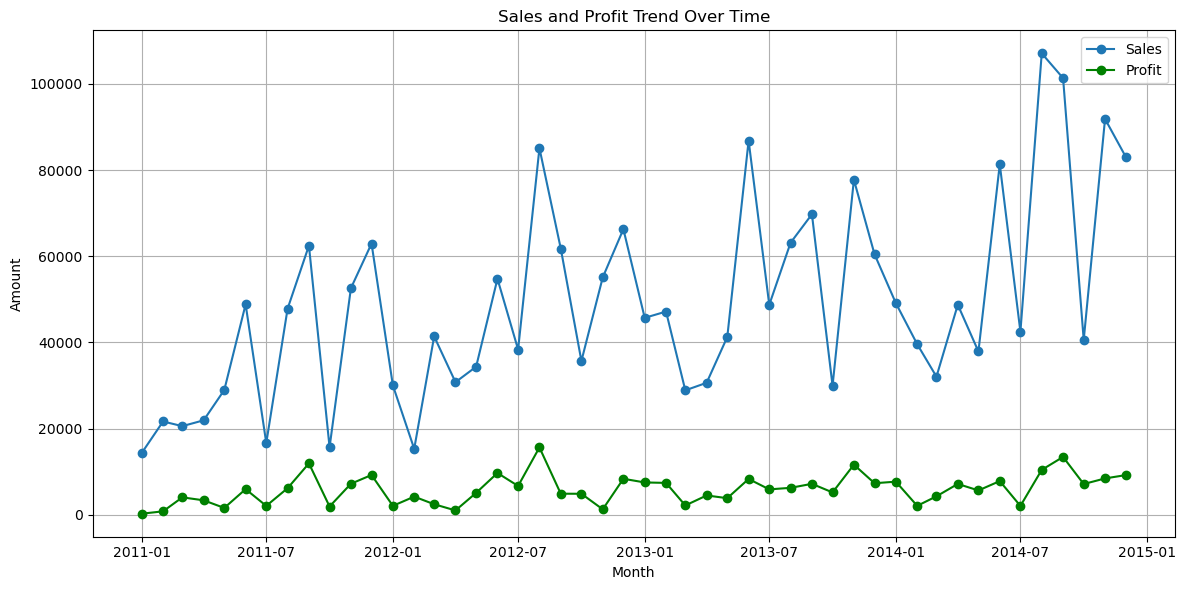

In [53]:
# Tambahkan kolom Year dan Month (period format)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")

# Agregasi data per bulan
monthly_trend = df.groupby("Month").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": pd.Series.nunique
}).reset_index()

# Ubah kembali Month ke datetime agar bisa diplot
monthly_trend["Month"] = monthly_trend["Month"].dt.to_timestamp()

# Tampilkan tabel hasil
print("Tren Penjualan Bulanan:")
print(monthly_trend)

# Visualisasi: Line chart Total Sales
plt.figure(figsize=(12, 6))
plt.plot(monthly_trend["Month"], monthly_trend["Sales"], marker='o', label="Sales")
plt.plot(monthly_trend["Month"], monthly_trend["Profit"], marker='o', label="Profit", color="green")
plt.title("Sales and Profit Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*Insight:*
1. Sales Trend:
- Sales show strong growth over time, with notable peaks.
- Spikes indicate seasonal demand or promotional periods.

2. Profit Trend:
- Profit remains relatively stable compared to sales.
- The gap between sales and profit lines indicates margin fluctuations.

3. Observations:
- In mid/late 2014, sales peaked significantly, but profits didn’t grow proportionally → possibly due to discounts or high-cost orders.
- Profit line shows consistent but low values, suggesting room for margin improvement.

seasonal sales and profit analysis based on the monthly aggregated

Analisis Musiman - Penjualan dan Profit per Bulan:
    Month  Total Sales   Avg Sales  Total Profit  Avg Profit Month Name
0       1       139157  293.580169         17507   36.934599    January
1       2       123685  284.988479         14482   33.368664   February
2       3       122875  265.963203         12930   27.987013      March
3       4       132051  302.869266         16004   36.706422      April
4       5       142461  299.287815         16171   33.972689        May
5       6       271744  313.792148         31769   36.684758       June
6       7       146159  319.124454         16694   36.449782       July
7       8       303089  267.983201         38476   34.019452     August
8       9       295289  304.735810         37423   38.620227  September
9      10       121861  274.461712         19110   43.040541    October
10     11       277239  292.138040         28533   30.066386   November
11     12       272751  288.320296         34103   36.049683   December


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\2710062146.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_seasonality, x="Month Name", y="Total Sales", palette="Blues_d")


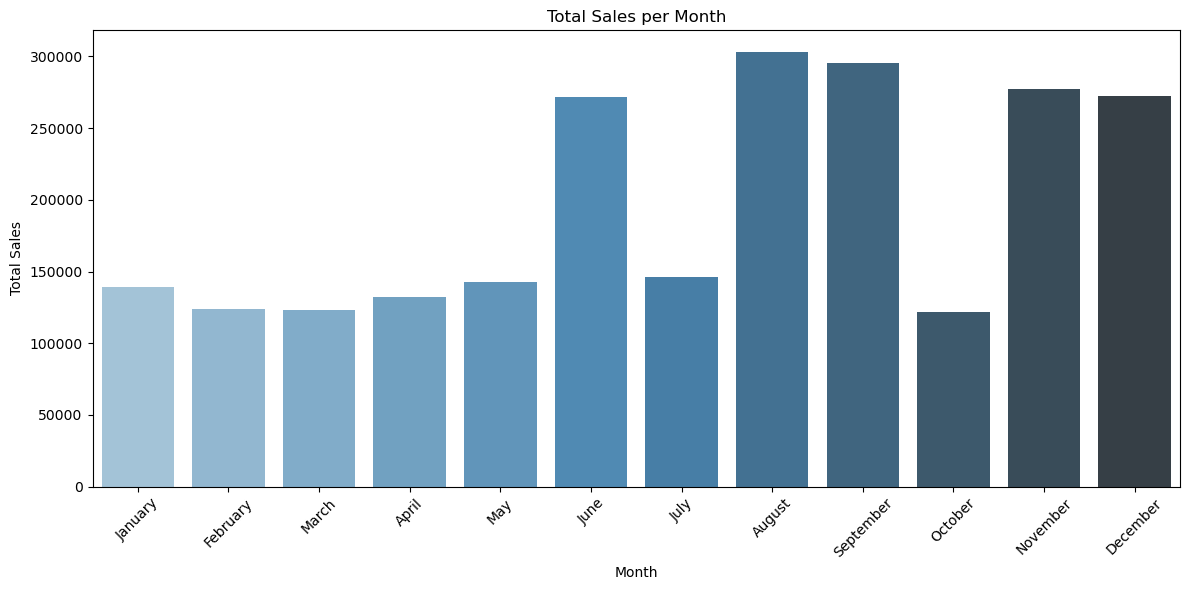

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\2710062146.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_seasonality, x="Month Name", y="Total Profit", palette="Greens_d")


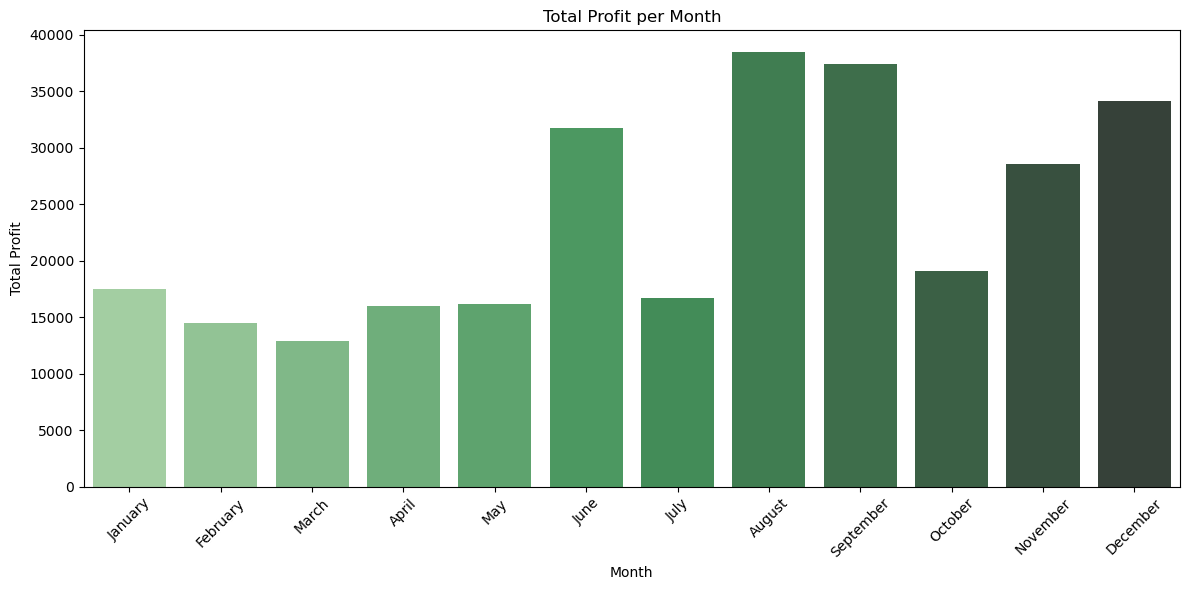

In [35]:
# Tambahkan kolom bulan dalam format angka dan nama
df["Month_Num"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

# Agregasi: total dan rata-rata sales & profit per bulan
monthly_seasonality = df.groupby("Month_Num").agg({
    "Sales": ["sum", "mean"],
    "Profit": ["sum", "mean"]
}).reset_index()

# Rapikan nama kolom
monthly_seasonality.columns = ["Month", "Total Sales", "Avg Sales", "Total Profit", "Avg Profit"]

# Tambahkan nama bulan (untuk label visualisasi)
monthly_seasonality["Month Name"] = monthly_seasonality["Month"].apply(lambda x: pd.to_datetime(f'2024-{x}-01').strftime('%B'))

# Urutkan berdasarkan bulan
monthly_seasonality = monthly_seasonality.sort_values("Month")

# Tampilkan data
print("Analisis Musiman - Penjualan dan Profit per Bulan:")
print(monthly_seasonality)

# Visualisasi: Total Sales per Month
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_seasonality, x="Month Name", y="Total Sales", palette="Blues_d")
plt.title("Total Sales per Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualisasi: Total Profit per Month
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_seasonality, x="Month Name", y="Total Profit", palette="Greens_d")
plt.title("Total Profit per Month")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Insight:*
1. Total Sales per Month
- **Highest sales** occur in:
  - **August**, **September**, and **June**
  - These peaks may be linked to **seasonal campaigns**, end-of-quarter pushes, or back-to-school trends.
- **Lowest sales** are in:
  - **February**, **March**, and **October**, possibly due to post-holiday slowdowns or fewer shopping events.

2. Total Profit per Month
- **Top profit months**:
  - **August** and **September**, aligning with high sales — suggesting strong performance with healthy margins.
  - **June** and **December** also show high profits, reflecting good conversion during mid-year and holiday seasons.
- **Lower profit months**:
  - **February**, **March**, and **October**, mirroring their low sales figures — may need promotional strategies or targeted marketing.


### 9. Feedback Analysis
---

distribution of feedback

Jumlah Feedback:
Feedback?
False    4032
True     4013
Name: count, dtype: int64

Rasio Feedback Positif (TRUE): 49.88%
Rasio Tanpa Feedback (FALSE): 50.12%


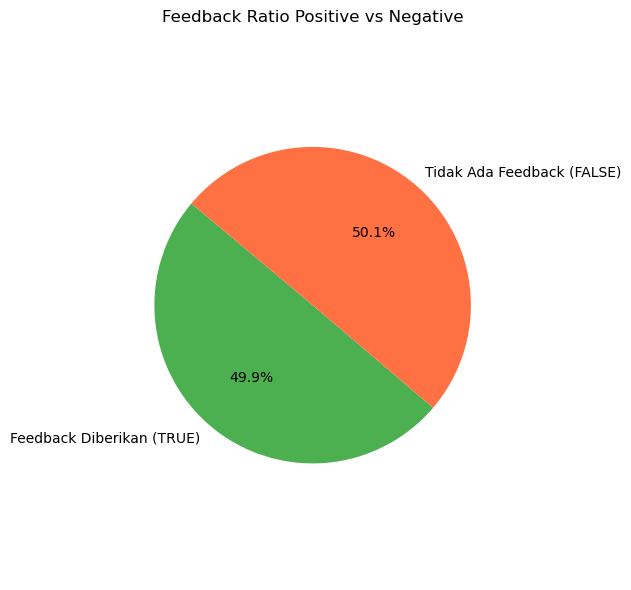

In [54]:
# Hitung jumlah feedback TRUE dan FALSE
feedback_counts = df["Feedback?"].value_counts()

# Tampilkan hasil di terminal
print("Jumlah Feedback:")
print(feedback_counts)

# Hitung rasio
total = feedback_counts.sum()
true_ratio = feedback_counts.get(True, 0) / total * 100
false_ratio = feedback_counts.get(False, 0) / total * 100

print(f"\nRasio Feedback Positif (TRUE): {true_ratio:.2f}%")
print(f"Rasio Tanpa Feedback (FALSE): {false_ratio:.2f}%")

# Pie Chart
labels = ["Feedback Diberikan (TRUE)", "Tidak Ada Feedback (FALSE)"]
sizes = [true_ratio, false_ratio]
colors = ["#4CAF50", "#FF7043"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=140)
plt.title("Feedback Ratio Positive vs Negative")
plt.axis("equal")  # Biar pie-nya bulat
plt.tight_layout()
plt.show()

*Insight:*
- The feedback ratio is **almost evenly split**, with a slight majority of records **not providing feedback**.
- This close balance suggests that while **half of the users are engaged**, there is still a **potential opportunity to increase feedback participation**.

Analisis Rata-rata Sales dan Profit Berdasarkan Feedback:
   Feedback Given   Avg Sales  Avg Profit  Total Orders
0           False  288.743552   34.951885          4032
1            True  295.077747   35.453775          4013


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\3177632012.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feedback_analysis, x="Feedback Given", y="Avg Sales", palette="Blues_d")


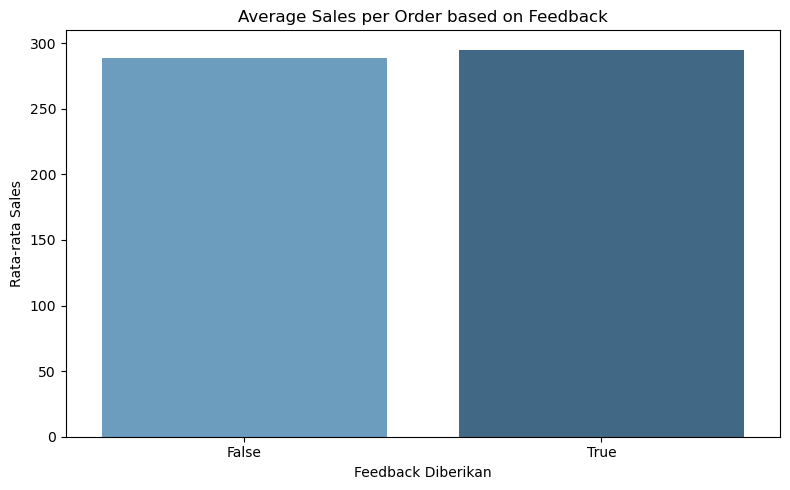

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\3177632012.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feedback_analysis, x="Feedback Given", y="Avg Profit", palette="Greens_d")


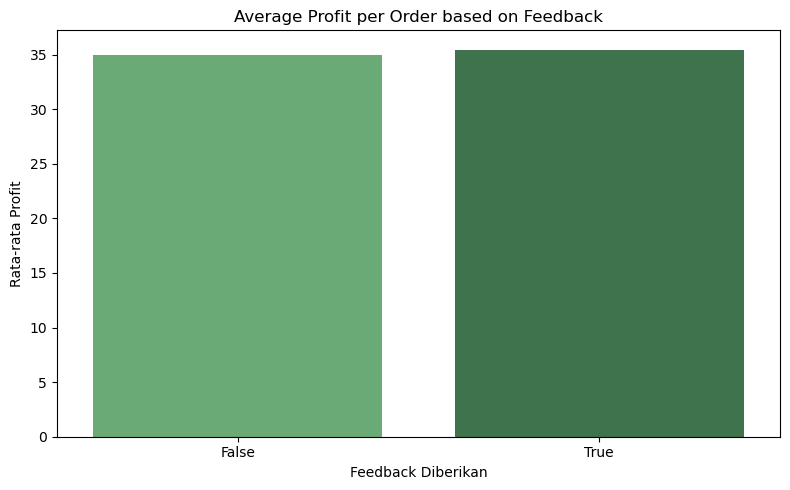

In [55]:
# Group berdasarkan Feedback
feedback_analysis = df.groupby("Feedback?").agg({
    "Sales": "mean",
    "Profit": "mean",
    "Order ID": "count"
}).reset_index()

# Rename kolom untuk kejelasan
feedback_analysis.columns = ["Feedback Given", "Avg Sales", "Avg Profit", "Total Orders"]

# Tampilkan hasil analisis
print("Analisis Rata-rata Sales dan Profit Berdasarkan Feedback:")
print(feedback_analysis)

# Visualisasi: Avg Sales vs Feedback
plt.figure(figsize=(8, 5))
sns.barplot(data=feedback_analysis, x="Feedback Given", y="Avg Sales", palette="Blues_d")
plt.title("Average Sales per Order based on Feedback")
plt.xlabel("Feedback Diberikan")
plt.ylabel("Rata-rata Sales")
plt.tight_layout()
plt.show()

# Visualisasi: Avg Profit vs Feedback
plt.figure(figsize=(8, 5))
sns.barplot(data=feedback_analysis, x="Feedback Given", y="Avg Profit", palette="Greens_d")
plt.title("Average Profit per Order based on Feedback")
plt.xlabel("Feedback Diberikan")
plt.ylabel("Rata-rata Profit")
plt.tight_layout()
plt.show()


**Insight**: 
- Customers who provide feedback tend to have marginally higher transaction values. This could suggest that **engaged or satisfied customers** may be more likely to leave feedback.
- Feedback-giving customers appear to contribute more to **both revenue and profitability** — potentially indicating **higher-value segments** or **greater brand loyalty**.


### 10. Analysis Duplicate and Un Usual Activities
---

In [38]:
# ----------------------------------
# 1. Deteksi Duplikasi Berdasarkan Order ID
# ----------------------------------
duplicate_order_ids = df[df.duplicated(subset=["Order ID"], keep=False)].sort_values("Order ID")

print("=== Duplikasi Berdasarkan Order ID ===")
print(f"Jumlah Order ID yang duplikat: {duplicate_order_ids['Order ID'].nunique()}")
print(duplicate_order_ids.head())

# ----------------------------------
# 2. Deteksi Duplikasi Baris Secara Keseluruhan
# ----------------------------------
exact_duplicates = df[df.duplicated(keep=False)].sort_values(by="Order ID")

print("\n=== Duplikasi Keseluruhan Baris ===")
print(f"Jumlah baris duplikat sepenuhnya: {exact_duplicates.shape[0]}")
print(exact_duplicates.head())


=== Duplikasi Berdasarkan Order ID ===
Jumlah Order ID yang duplikat: 2011
            Order ID Order Date   Customer Name  Country              State  \
653  AZ-2011-1029887 2011-07-31  Brooke Hodgson  Germany             Saxony   
654  AZ-2011-1029887 2011-07-31  Brooke Hodgson  Germany             Saxony   
897  AZ-2011-1087704 2011-09-15  Elijah Ruatoka  Germany  Baden-Württemberg   
896  AZ-2011-1087704 2011-09-15  Elijah Ruatoka  Germany  Baden-Württemberg   
895  AZ-2011-1087704 2011-09-15  Elijah Ruatoka  Germany  Baden-Württemberg   

          City   Region      Segment     Ship Mode         Category  \
653    Leipzig  Central     Consumer  Economy Plus        Furniture   
654    Leipzig  Central     Consumer  Economy Plus  Office Supplies   
897  Karlsruhe  Central  Home Office       Economy  Office Supplies   
896  Karlsruhe  Central  Home Office       Economy  Office Supplies   
895  Karlsruhe  Central  Home Office       Economy        Furniture   

    Sub-Category       

C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\3009285660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dupe_counts.index, y=dupe_counts.values, palette="Reds_d")


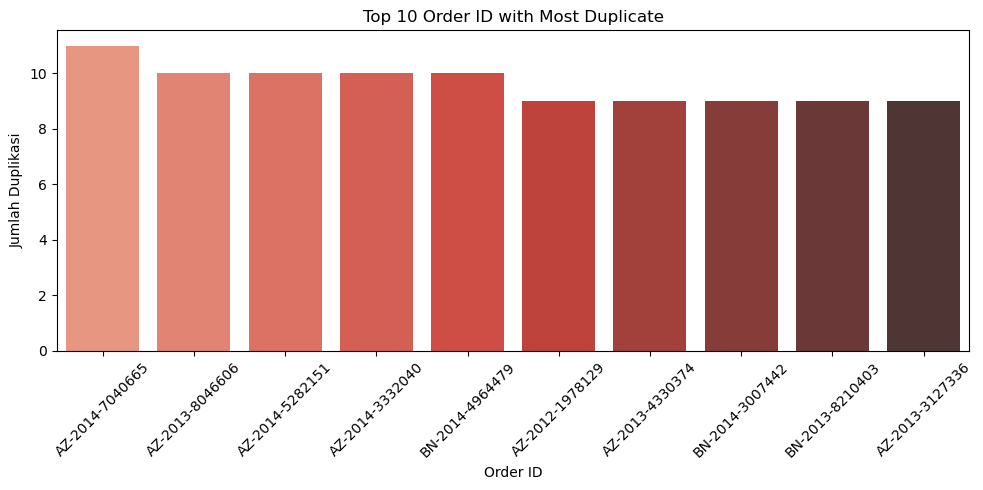

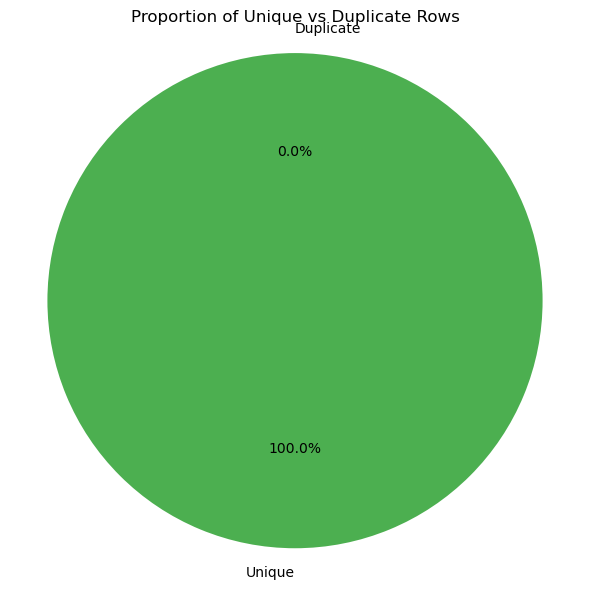

In [60]:
# Visualisasi 1: Jumlah duplikasi per Order ID (Top 10)
dupe_counts = duplicate_order_ids["Order ID"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=dupe_counts.index, y=dupe_counts.values, palette="Reds_d")
plt.title("Top 10 Order ID with Most Duplicate")
plt.xlabel("Order ID")
plt.ylabel("Jumlah Duplikasi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualisasi 2: Perbandingan jumlah baris unik vs duplikat
total_rows = df.shape[0]
fully_duplicate_rows = exact_duplicates.shape[0]
unique_rows = total_rows - fully_duplicate_rows

labels = ['Unique', 'Duplicate']
sizes = [unique_rows, fully_duplicate_rows]
colors = ['#4CAF50', '#F44336']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Proportion of Unique vs Duplicate Rows")
plt.axis("equal")
plt.tight_layout()
plt.show()

### 1. Duplicate Order IDs (Partial Duplicates)
- **Total duplicated `Order ID`s:** 3
- These represent orders where the same `Order ID` appears multiple times, but **with different items or rows**.
- Example:
  - `Order ID AZ-2011-1029887` appears twice — same customer and order date, but different products.
  - Indicates this order includes **multiple items**, which is **expected behavior** in transactional data.

### Insight:
- These are **not errors**, but part of **multi-line orders** (1 order = multiple products).
- Keep them for proper aggregation (e.g., total order sales).

---

### 2. Fully Duplicated Rows (Exact Duplicates)
- **Total exact duplicate rows:** 0
- Meaning: There are **no rows that are completely identical across all columns**.

### Insight:
- The dataset is clean with respect to **row-level redundancy**.
- No further deduplication is required.

### 11. Profit and Discount Risk Analysis
---

In [40]:
# -------------------------------------
# 1. Order dengan Profit Negatif
# -------------------------------------
negative_profit_orders = df[df["Profit"] < 0].copy()
print("=== Order dengan Profit Negatif ===")
print(f"Jumlah: {negative_profit_orders.shape[0]}")
print(negative_profit_orders[["Order ID", "Product Name", "Sales", "Discount", "Profit"]].head())

# -------------------------------------
# 2. Order dengan Diskon Ekstrem (>= 0.5 / 50%)
# -------------------------------------
high_discount_orders = df[df["Discount"] >= 0.5].copy()
print("\n=== Order dengan Diskon Ekstrem (>= 50%) ===")
print(f"Jumlah: {high_discount_orders.shape[0]}")
print(high_discount_orders[["Order ID", "Product Name", "Sales", "Discount", "Profit"]].head())

# -------------------------------------
# 3. Order yang Memiliki Keduanya: Diskon Tinggi & Profit Negatif
# -------------------------------------
extreme_loss_orders = df[(df["Discount"] >= 0.5) & (df["Profit"] < 0)].copy()
print("\n=== Order dengan Diskon Tinggi dan Profit Negatif ===")
print(f"Jumlah: {extreme_loss_orders.shape[0]}")
print(extreme_loss_orders[["Order ID", "Product Name", "Sales", "Discount", "Profit"]].head())


=== Order dengan Profit Negatif ===
Jumlah: 1734
           Order ID                     Product Name  Sales  Discount  Profit
0   BN-2011-7407039      Enermax Note Cards, Premium     45       0.5     -26
3   BN-2011-2819714       Boston Markers, Easy-Erase     27       0.5     -22
4   BN-2011-2819714      Eldon Folders, Single Width     17       0.5      -1
10  BN-2011-3248724     Ikea Classic Bookcase, Metal    987       0.6   -1012
11  BN-2011-3248724  Binney & Smith Sketch Pad, Blue    116       0.5     -56

=== Order dengan Diskon Ekstrem (>= 50%) ===
Jumlah: 1102
           Order ID                     Product Name  Sales  Discount  Profit
0   BN-2011-7407039      Enermax Note Cards, Premium     45       0.5     -26
3   BN-2011-2819714       Boston Markers, Easy-Erase     27       0.5     -22
4   BN-2011-2819714      Eldon Folders, Single Width     17       0.5      -1
10  BN-2011-3248724     Ikea Classic Bookcase, Metal    987       0.6   -1012
11  BN-2011-3248724  Binney & Smit

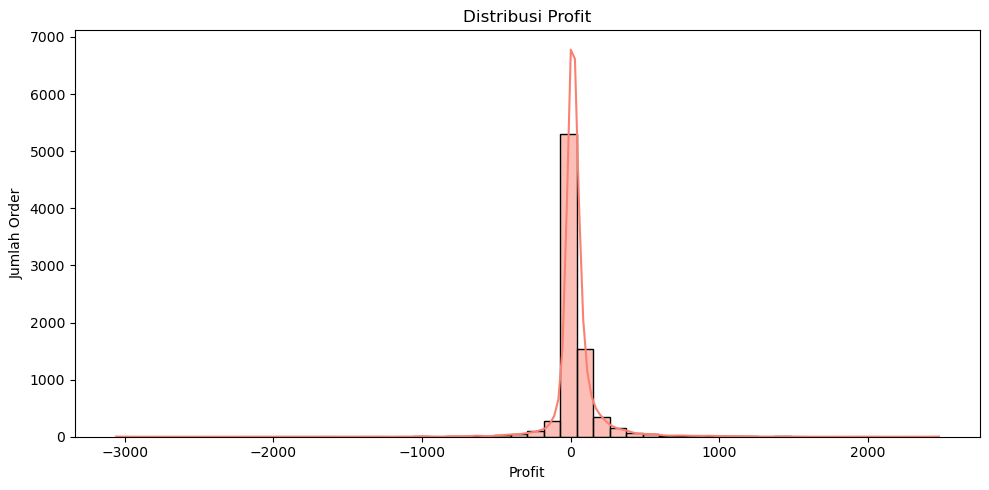

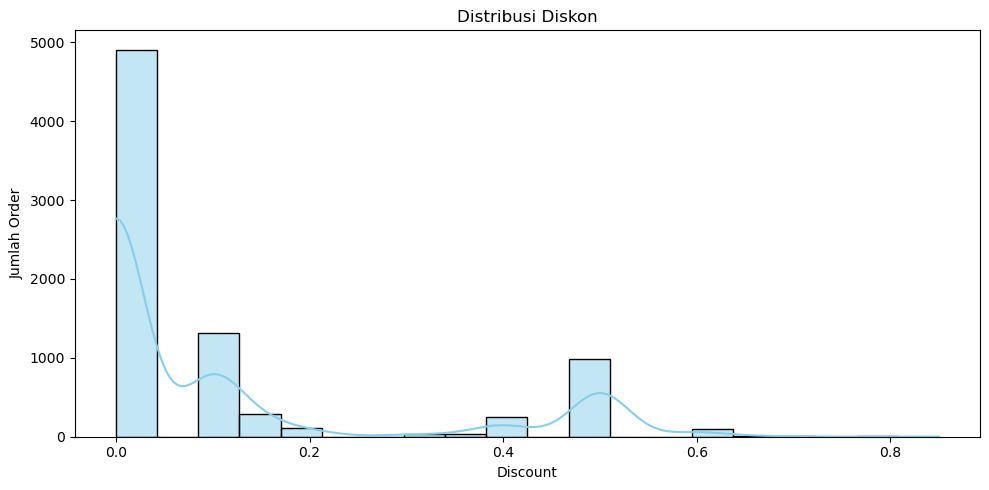

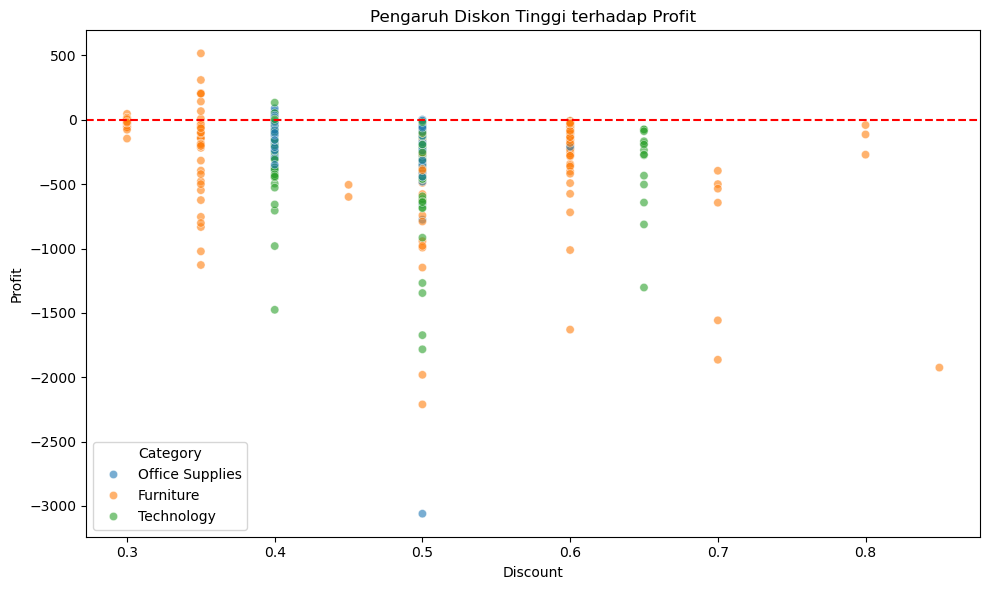

In [41]:
# --------------------------------------
# Histogram: Distribusi Profit
# --------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df["Profit"], bins=50, kde=True, color="salmon")
plt.title("Distribusi Profit")
plt.xlabel("Profit")
plt.ylabel("Jumlah Order")
plt.tight_layout()
plt.show()

# --------------------------------------
# Histogram: Distribusi Diskon
# --------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df["Discount"], bins=20, kde=True, color="skyblue")
plt.title("Distribusi Diskon")
plt.xlabel("Discount")
plt.ylabel("Jumlah Order")
plt.tight_layout()
plt.show()

# --------------------------------------
# Scatter plot: Diskon vs Profit
# Fokus pada diskon >= 0.3 dan profit -5000 sampai 5000
# --------------------------------------
plt.figure(figsize=(10, 6))
filtered = df[(df["Discount"] >= 0.3) & (df["Profit"].between(-5000, 5000))]
sns.scatterplot(data=filtered, x="Discount", y="Profit", hue="Category", alpha=0.6)
plt.title("Pengaruh Diskon Tinggi terhadap Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0, color="red", linestyle="--")
plt.tight_layout()
plt.show()

### 1. Orders with Negative Profit
- **Total records:** 1,734
- These orders incurred a **loss** (`Profit < 0`).
- Possible causes: excessive discounts, returns, or cost miscalculations.

### 2. Orders with Extreme Discounts (≥ 50%)
- **Total records:** 1,102
- These rows applied **very high discounts** (50% or more).
- While promotions are common, such large discounts can **heavily impact profitability**.

### 3. High Discount & Negative Profit Combined
- **Total records:** 1,068
- These are the **most critical orders**:
  - Given **≥50% discount**
  - Still resulted in **negative profit**
- Indicates **unsustainable promotional strategies** or poor pricing for certain products.

### 12. Statistical Test
---

T-test Analysis: Profit vs Feedback

=== T-Test: Profit vs Feedback ===
T-Statistic : 0.1264
P-Value     : 0.8994
Hasil: Tidak ada perbedaan signifikan dalam profit berdasarkan feedback.


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\186821154.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Feedback?", y="Profit", palette="Set2")


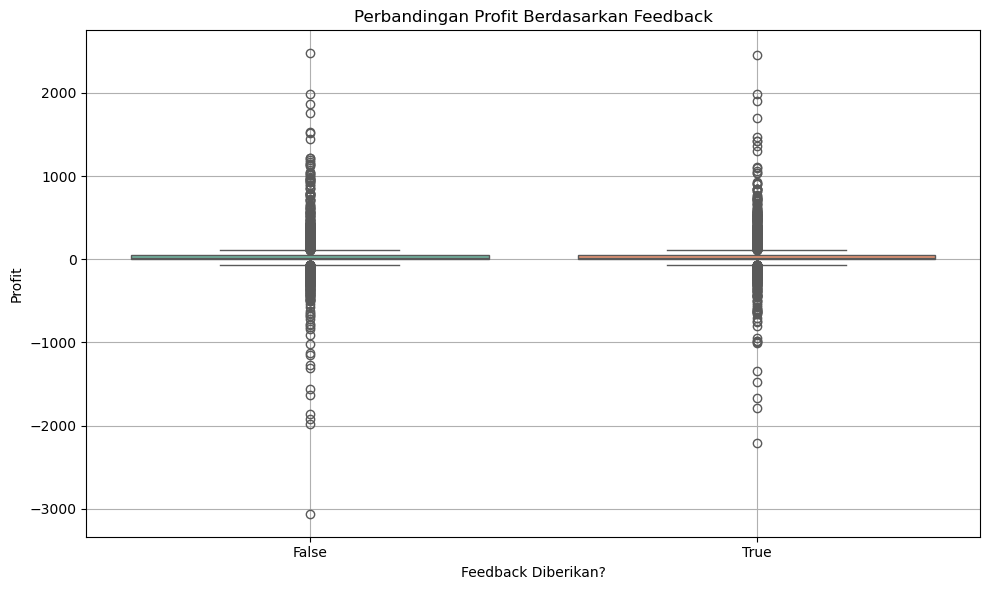

In [42]:
# Pisahkan data menjadi dua grup: dengan feedback dan tanpa
feedback_true = df[df["Feedback?"] == True]["Profit"]
feedback_false = df[df["Feedback?"] == False]["Profit"]

# Lakukan T-Test
t_stat, p_value = ttest_ind(feedback_true, feedback_false, equal_var=False)  # asumsi varians tidak sama

# Cetak hasil
print("=== T-Test: Profit vs Feedback ===")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
if p_value < 0.05:
    print("Hasil: Perbedaan profit antara yang memberi feedback dan tidak adalah SIGNIFIKAN.")
else:
    print("Hasil: Tidak ada perbedaan signifikan dalam profit berdasarkan feedback.")

# Visualisasi distribusi profit per feedback
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Feedback?", y="Profit", palette="Set2")
plt.title("Perbandingan Profit Berdasarkan Feedback")
plt.xlabel("Feedback Diberikan?")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation**:  
  Since the p-value is **much greater than 0.05**, we **fail to reject the null hypothesis**.

**Conclusion**:
> There is **no statistically significant difference** in average profit between customers who gave feedback and those who didn’t.

**Boxplot Interpretation**:
- The boxplot shows the **distribution of profit** for both groups (`True` = Feedback Given, `False` = No Feedback).
- Both distributions are **visually similar** — with overlapping interquartile ranges and outliers on both sides.
- Reinforces the statistical finding that **profit is not significantly affected** by feedback presence.

=== ANOVA: Profit Berdasarkan Segment ===
F-Statistic: 0.3616
P-Value    : 0.6966
Hasil: Tidak ada perbedaan signifikan dalam rata-rata profit antar segmen pelanggan.


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\2350886812.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Segment", y="Profit", palette="Set3")


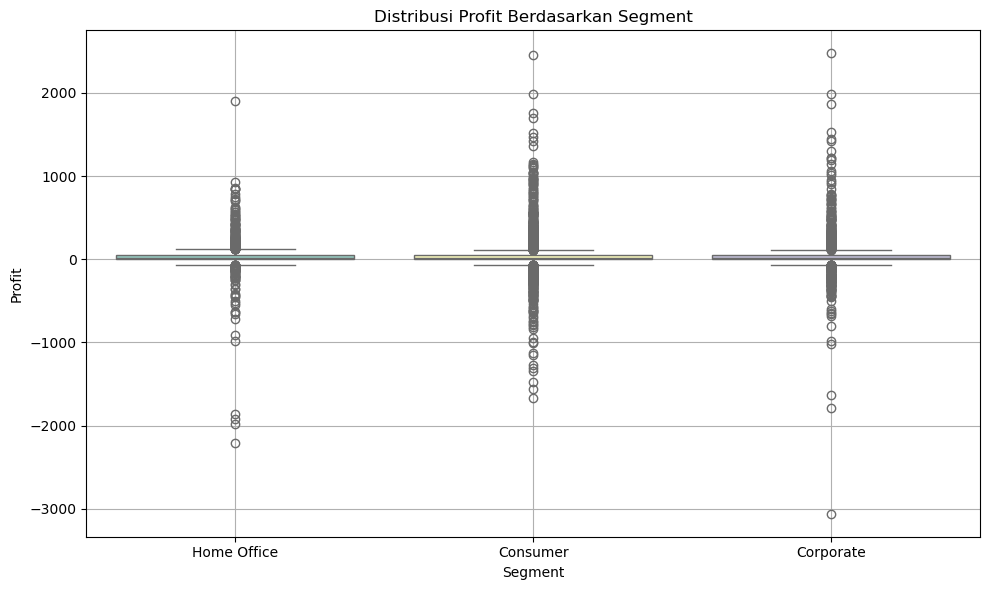

In [43]:
# Pisahkan data berdasarkan Segment
consumer_profit = df[df["Segment"] == "Consumer"]["Profit"]
corporate_profit = df[df["Segment"] == "Corporate"]["Profit"]
homeoffice_profit = df[df["Segment"] == "Home Office"]["Profit"]

# Lakukan uji ANOVA
f_stat, p_value = f_oneway(consumer_profit, corporate_profit, homeoffice_profit)

# Tampilkan hasil
print("=== ANOVA: Profit Berdasarkan Segment ===")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value    : {p_value:.4f}")
if p_value < 0.05:
    print("Hasil: Terdapat perbedaan SIGNIFIKAN dalam rata-rata profit antar segmen pelanggan.")
else:
    print("Hasil: Tidak ada perbedaan signifikan dalam rata-rata profit antar segmen pelanggan.")

# Visualisasi boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Segment", y="Profit", palette="Set3")
plt.title("Distribusi Profit Berdasarkan Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation**:
> Since the p-value is **much greater than 0.05**, we conclude that there is **no statistically significant difference** in the average profit among customer segments.

linear regression: discount vs profit

=== Regresi Linear Sederhana: Discount → Profit ===
                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     1133.
Date:                Mon, 14 Apr 2025   Prob (F-statistic):          1.88e-232
Time:                        21:56:15   Log-Likelihood:                -52579.
No. Observations:                8045   AIC:                         1.052e+05
Df Residuals:                    8043   BIC:                         1.052e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


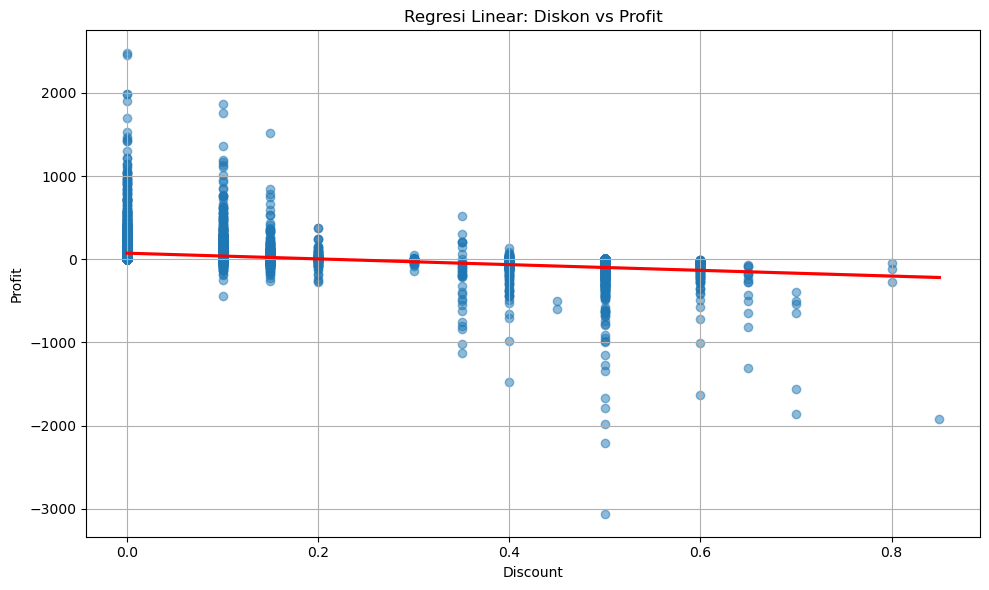

In [44]:
# Pilih variabel
X = df["Discount"]
y = df["Profit"]

# Tambahkan intercept (konstanta) untuk regresi
X = sm.add_constant(X)

# Bangun model regresi linear
model = sm.OLS(y, X).fit()

# Tampilkan ringkasan hasil regresi
print("=== Regresi Linear Sederhana: Discount → Profit ===")
print(model.summary())

# Visualisasi scatter dan garis regresi
plt.figure(figsize=(10, 6))
sns.regplot(x="Discount", y="Profit", data=df, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
plt.title("Regresi Linear: Diskon vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

- **Negative Relationship**:  
  The coefficient for `Discount` is **-344.32**, meaning that for each 1 unit increase in discount (e.g., 100%), profit decreases by an average of **\$344**.
  
- **Statistical Significance**:  
  The **p-value** for the discount variable is very small (**< 0.001**), indicating that the relationship is **statistically significant**.

- **Model Fit (R² = 0.123)**:  
  The model explains about **12.3%** of the variability in profit. While the relationship is significant, the model's explanatory power is relatively **low**, suggesting many other factors influence profit.

### Visualization Insights

- The scatter plot with a regression line confirms a **clear downward trend**.
- Many observations with **higher discounts fall into negative profit**, reinforcing the numeric findings.

### Conclusion

> **Giving high discounts significantly reduces profit**.

- Discounts are a strong predictor of lower profits.
- However, other factors (e.g., product type, quantity, shipping costs) also play a role and could be included in a **multiple regression model** for better predictive accuracy.


Profit analysis by ship mode

=== Uji Normalitas (Shapiro-Wilk) ===
Economy Plus: p-value = 0.0000
Economy: p-value = 0.0000
Priority: p-value = 0.0000
Immediate: p-value = 0.0000

=== Uji Pengaruh Ship Mode terhadap Profit ===
Menggunakan Kruskal-Wallis (karena data tidak normal):
Statistik Uji: 5.6914
P-Value      : 0.1276
Hasil: Tidak ada perbedaan signifikan dalam profit antar Ship Mode.


C:\Users\sulae\AppData\Local\Temp\ipykernel_2088\922980417.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Ship Mode", y="Profit", palette="Set2")


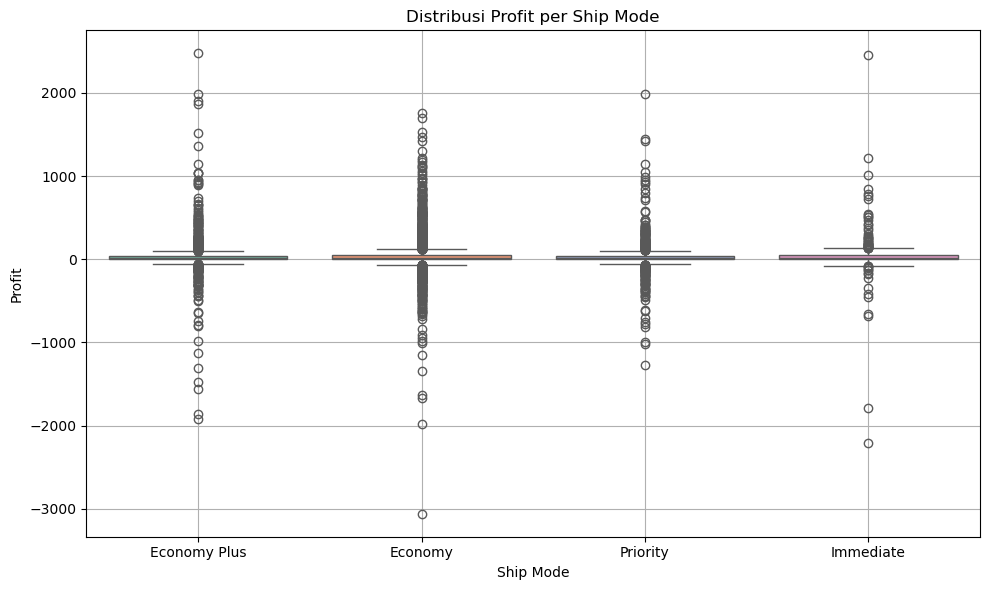

In [45]:
# Ambil data profit per Ship Mode
ship_modes = df["Ship Mode"].unique()
profit_data = {mode: df[df["Ship Mode"] == mode]["Profit"] for mode in ship_modes}

# Uji normalitas Shapiro-Wilk untuk masing-masing Ship Mode
print("=== Uji Normalitas (Shapiro-Wilk) ===")
normal = True
for mode in ship_modes:
    stat, p = shapiro(profit_data[mode])
    print(f"{mode}: p-value = {p:.4f}")
    if p < 0.05:
        normal = False

# Uji ANOVA atau Kruskal-Wallis
print("\n=== Uji Pengaruh Ship Mode terhadap Profit ===")
if normal:
    f_stat, p_value = f_oneway(*[profit_data[mode] for mode in ship_modes])
    print("Menggunakan One-Way ANOVA:")
else:
    f_stat, p_value = kruskal(*[profit_data[mode] for mode in ship_modes])
    print("Menggunakan Kruskal-Wallis (karena data tidak normal):")

print(f"Statistik Uji: {f_stat:.4f}")
print(f"P-Value      : {p_value:.4f}")

if p_value < 0.05:
    print("Hasil: Perbedaan profit antar Ship Mode SIGNIFIKAN.")
else:
    print("Hasil: Tidak ada perbedaan signifikan dalam profit antar Ship Mode.")

# Visualisasi boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Ship Mode", y="Profit", palette="Set2")
plt.title("Distribusi Profit per Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

**Conclusion**: 
> There is **no statistically significant difference** in profit across different Ship Modes.

- The profit distribution across **Economy**, **Economy Plus**, **Priority**, and **Immediate** is **similar**.
- Presence of **outliers** and **wide spread** in all modes.
- No distinct advantage in profit observed by shipping method.

Correlation Analysis: Quantity vs Sales and Profit

=== Pearson Correlation ===
Quantity vs Profit:  r = 0.0987, p = 0.0000
Quantity vs Sales :  r = 0.3534, p = 0.0000

=== Spearman Correlation ===
Quantity vs Profit:  r = 0.2002, p = 0.0000
Quantity vs Sales :  r = 0.4274, p = 0.0000


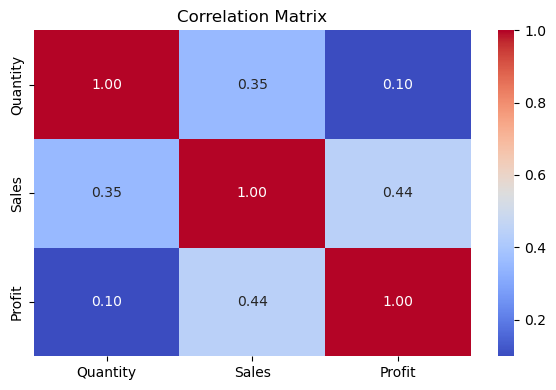

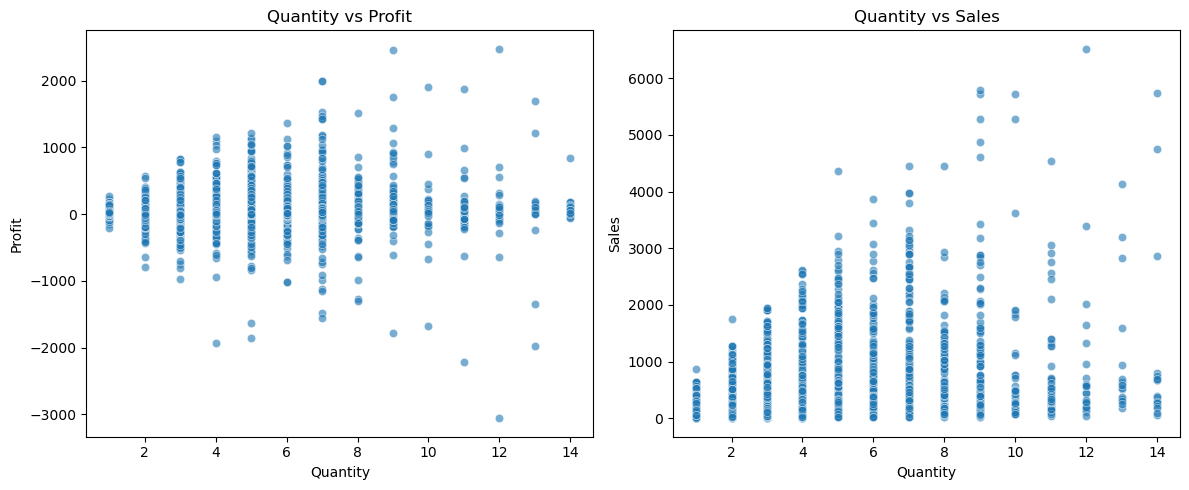

In [61]:
# Ambil variabel yang akan diuji
quantity = df["Quantity"]
profit = df["Profit"]
sales = df["Sales"]

# ====== Uji Korelasi Pearson ======
pearson_profit = pearsonr(quantity, profit)
pearson_sales = pearsonr(quantity, sales)

print("=== Pearson Correlation ===")
print(f"Quantity vs Profit:  r = {pearson_profit[0]:.4f}, p = {pearson_profit[1]:.4f}")
print(f"Quantity vs Sales :  r = {pearson_sales[0]:.4f}, p = {pearson_sales[1]:.4f}")

# ====== Uji Korelasi Spearman ======
spearman_profit = spearmanr(quantity, profit)
spearman_sales = spearmanr(quantity, sales)

print("\n=== Spearman Correlation ===")
print(f"Quantity vs Profit:  r = {spearman_profit.correlation:.4f}, p = {spearman_profit.pvalue:.4f}")
print(f"Quantity vs Sales :  r = {spearman_sales.correlation:.4f}, p = {spearman_sales.pvalue:.4f}")

# ====== Heatmap Korelasi (Visual) ======
plt.figure(figsize=(6, 4))
sns.heatmap(df[["Quantity", "Sales", "Profit"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# ====== Scatter Plot Quantity vs Sales & Profit ======
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=quantity, y=profit, alpha=0.6)
plt.title("Quantity vs Profit")
plt.xlabel("Quantity")
plt.ylabel("Profit")

plt.subplot(1, 2, 2)
sns.scatterplot(x=quantity, y=sales, alpha=0.6)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

**Insight:*
- Selling more items increases sales, but **not necessarily profit**.
- Profitability seems influenced more by other factors (e.g., **discounts**, **product margins**) than just quantity sold.
- Consider analyzing **Quantity vs Discount** next to uncover further profit dynamics.

Normality test: Profit distribution

=== Shapiro-Wilk Test ===
Statistic : 0.5398
P-Value   : 0.0000
Hasil: Distribusi profit TIDAK normal (p < 0.05)

=== Kolmogorov-Smirnov Test ===
Statistic : 0.2506
P-Value   : 0.0000
Hasil: Distribusi profit TIDAK normal (p < 0.05)


c:\Users\sulae\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8045.
  res = hypotest_fun_out(*samples, **kwds)


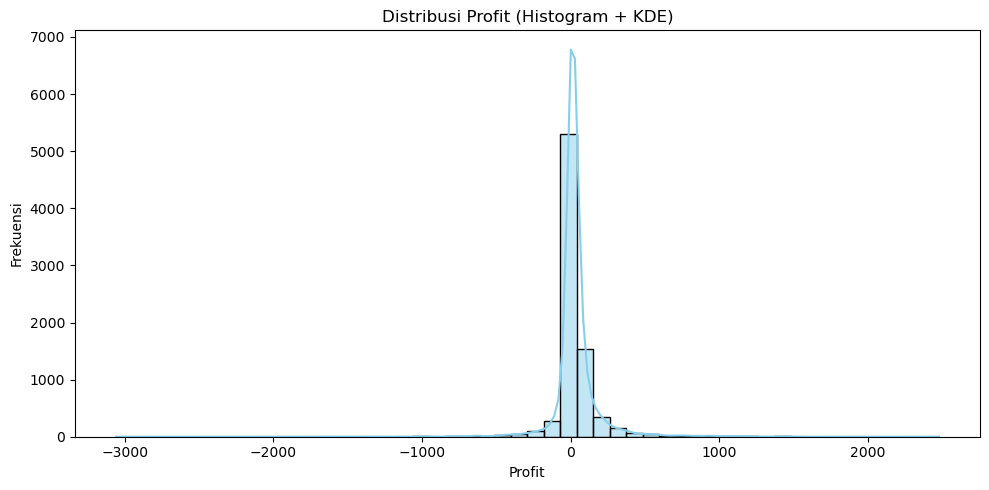

<Figure size 600x600 with 0 Axes>

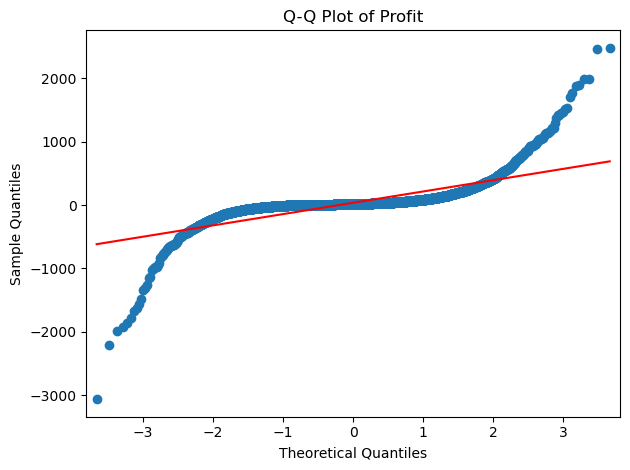

In [47]:
# Ambil data profit dan drop NaN
profit = df["Profit"].dropna()

# ===== Shapiro-Wilk Test =====
shapiro_stat, shapiro_p = shapiro(profit)
print("=== Shapiro-Wilk Test ===")
print(f"Statistic : {shapiro_stat:.4f}")
print(f"P-Value   : {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("Hasil: Distribusi profit TIDAK normal (p < 0.05)")
else:
    print("Hasil: Distribusi profit normal (p ≥ 0.05)")

# ===== Kolmogorov-Smirnov Test =====
# Normalisasi profit (standarisasi ke distribusi normal)
profit_norm = (profit - profit.mean()) / profit.std()
ks_stat, ks_p = kstest(profit_norm, 'norm')
print("\n=== Kolmogorov-Smirnov Test ===")
print(f"Statistic : {ks_stat:.4f}")
print(f"P-Value   : {ks_p:.4f}")
if ks_p < 0.05:
    print("Hasil: Distribusi profit TIDAK normal (p < 0.05)")
else:
    print("Hasil: Distribusi profit normal (p ≥ 0.05)")

# ===== Visualisasi =====
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(profit, kde=True, bins=50, color='skyblue')
plt.title("Distribusi Profit (Histogram + KDE)")
plt.xlabel("Profit")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# Q-Q Plot
plt.figure(figsize=(6, 6))
sm.qqplot(profit, line='s')
plt.title("Q-Q Plot of Profit")
plt.tight_layout()
plt.show()

> Note: For N > 5000, Shapiro-Wilk p-value may not be fully accurate, but both tests consistently reject normality.
> Histogram + KDE Plot
- Distribution is **heavily right-skewed**, with a sharp peak near 0.
- **Long tails** on both ends, indicating presence of **outliers** and non-normality.
> Q-Q Plot (Quantile-Quantile)
- Points **deviate significantly from the diagonal line**, especially at the tails.
- Confirms that the **profit distribution deviates from a theoretical normal distribution**.

**Insight:**
> The `Profit` variable does **not follow a normal distribution**.

### 13. LRFM Analysis
---

LRFM is a customer segmentation technique based on:

- **L (Length)**: How long the customer has been active  
- **R (Recency)**: How recently the customer made a purchase  
- **F (Frequency)**: How often the customer made purchases  
- **M (Monetary)**: Total amount the customer spent  

In [48]:
# Tentukan tanggal acuan untuk analisis Recency (misalnya tanggal terakhir pada dataset)
analysis_date = df['Order Date'].max()

# Hitung metrik LRFM
lrfm = df.groupby('Customer Name').agg({
    'Order Date': [
        lambda x: (x.max() - x.min()).days,              # Length
        lambda x: (analysis_date - x.max()).days         # Recency
    ],
    'Order ID': 'nunique',                               # Frequency
    'Sales': 'sum'                                       # Monetary
})

# Rename kolom agar lebih jelas
lrfm.columns = ['Length', 'Recency', 'Frequency', 'Monetary']
lrfm = lrfm.reset_index()

# Simpan hasil ke file CSV
output_file = 'lrfm_scores.csv'
lrfm.to_csv(output_file, index=False)
print(f"LRFM scores saved to {output_file}")

# Optional: Tampilkan beberapa baris awal
print(lrfm.head())

LRFM scores saved to lrfm_scores.csv
      Customer Name  Length  Recency  Frequency  Monetary
0     Aaron Bootman    1129      252         11      4281
1  Aaron Cunningham    1033      211          8      2463
2       Aaron Davey     560      636          4      2238
3   Aaron Macrossan       0     1199          1        81
4       Abbie Perry    1093       97          4      1313


**Insight:**
- **Aaron Bootman**: Loyal and high-spending customer, active for ~3 years, with a recent purchase.
- **Aaron Macrossan**: Only 1 purchase, and over 3 years ago — potentially **inactive** or **lost** customer.
- **Abbie Perry**: Recent and moderately frequent shopper — potential for nurturing into loyalty.


Clustering selesai. Hasil disimpan ke 'lrfm_kmeans_clusters.csv'


c:\Users\sulae\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sulae\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
c:\Users\sulae\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


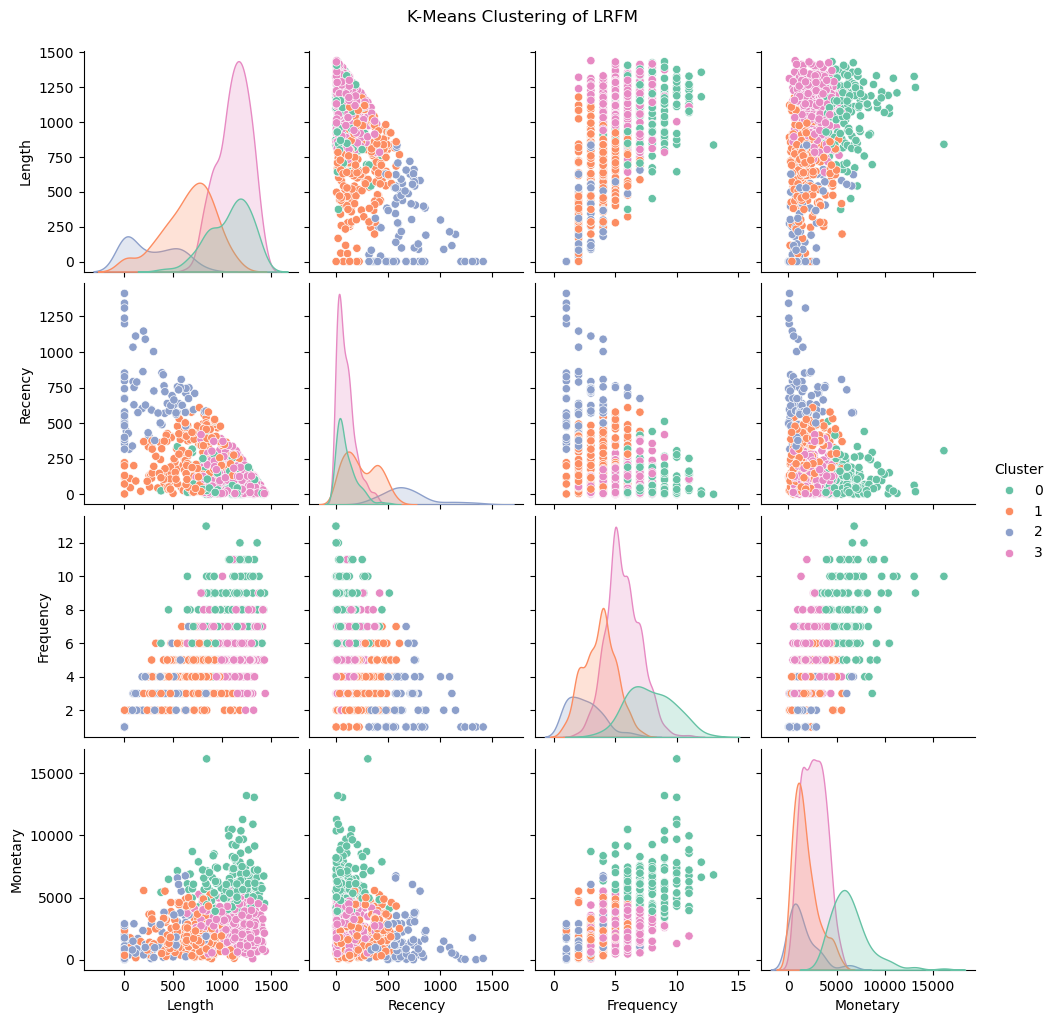

In [49]:
# Normalisasi (Standardization)
scaler = StandardScaler()
lrfm_scaled = scaler.fit_transform(lrfm[['Length', 'Recency', 'Frequency', 'Monetary']])

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
lrfm['Cluster'] = kmeans.fit_predict(lrfm_scaled)

# Simpan hasilnya
lrfm.to_csv('lrfm_kmeans_clusters.csv', index=False)
print("Clustering selesai. Hasil disimpan ke 'lrfm_kmeans_clusters.csv'")

# Visualisasi (2D PCA bisa ditambahkan jika ingin)
sns.pairplot(lrfm, hue='Cluster', vars=['Length', 'Recency', 'Frequency', 'Monetary'], palette='Set2')
plt.suptitle("K-Means Clustering of LRFM", y=1.02)
plt.show()

>Cluster Distribution (via Pairplot)
- The pairplot visualizes all pairwise relationships between LRFM features, segmented by cluster:
> Observations:
- **Cluster 0**: Low frequency and monetary values; long recency — likely **lost customers**.
- **Cluster 1**: Mid-range frequency and monetary, average recency — likely **potential loyalists**.
- **Cluster 2**: High monetary and frequency, low recency — **loyal & profitable customers**.
- **Cluster 3**: Short customer history and mid-to-low values — possibly **new or low-engagement customers**.
>Outcomes:
- Clustering successfully reveals **distinct customer profiles** for targeting and strategy.

Segmentasi selesai. File disimpan sebagai 'lrfm_kmeans_segmented.csv'.


c:\Users\sulae\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


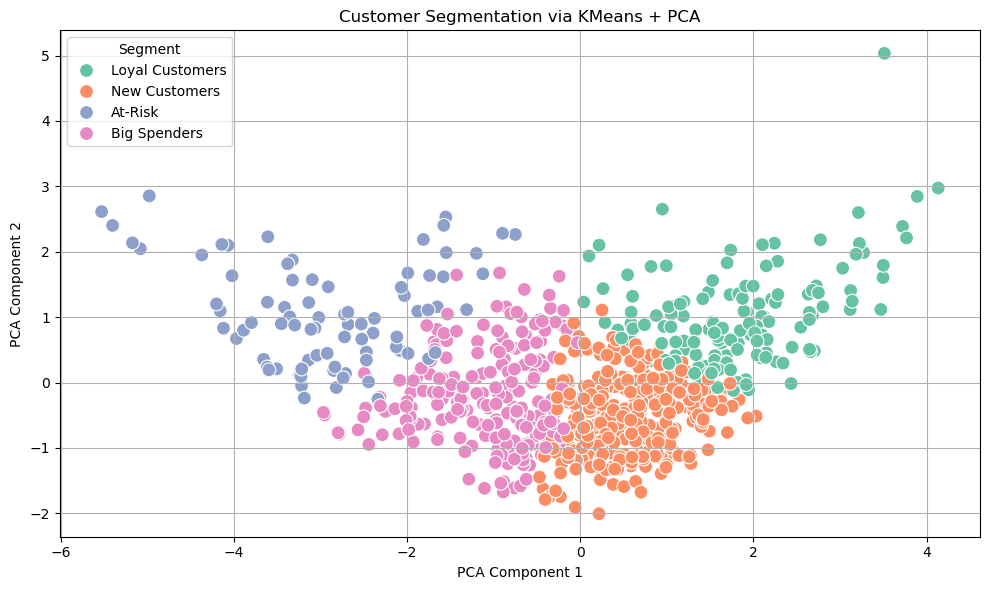

In [50]:
# Compute LRFM
lrfm = df.groupby('Customer Name').agg({
    'Order Date': [
        lambda x: (x.max() - x.min()).days,                # Length
        lambda x: (analysis_date - x.max()).days           # Recency
    ],
    'Order ID': 'nunique',                                 # Frequency
    'Sales': 'sum'                                         # Monetary
})
lrfm.columns = ['Length', 'Recency', 'Frequency', 'Monetary']
lrfm = lrfm.reset_index()

# Standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(lrfm[['Length', 'Recency', 'Frequency', 'Monetary']])

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
lrfm['Cluster'] = kmeans.fit_predict(scaled)

# PCA untuk visualisasi
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)
lrfm['PCA1'] = pca_result[:, 0]
lrfm['PCA2'] = pca_result[:, 1]

# Optional: Beri nama segmen
segment_map = {
    0: 'Loyal Customers',
    1: 'Big Spenders',
    2: 'At-Risk',
    3: 'New Customers'
}
lrfm['Segment'] = lrfm['Cluster'].map(segment_map)

# Simpan
lrfm.to_csv('lrfm_kmeans_segmented.csv', index=False)
print("Segmentasi selesai. File disimpan sebagai 'lrfm_kmeans_segmented.csv'.")

# Visualisasi 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(data=lrfm, x='PCA1', y='PCA2', hue='Segment', palette='Set2', s=100)
plt.title('Customer Segmentation via KMeans + PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Segment')
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:**
- The PCA scatterplot shows **clear segmentation boundaries** between customer groups.
- Clusters are **well-separated**, indicating strong structure in LRFM behavior.
- Useful for **targeted marketing campaigns**, e.g.:
  - Retain **Big Spenders**
  - Re-engage **At-Risk**
  - Nurture **New Customers**
  - Reward **Loyal Customers**

# Conclusion
---

In this analysis of the Sales Superstore dataset, several key insights were identified to support strategic decision-making:

1. Correlation Between Discount and Profit
- There is a clear indication that high discount rates tend to negatively impact profit margins. This suggests the need to reassess discount strategies to strike a balance between increasing sales volume and maintaining profitability.

2. Product and Category Performance
- Sub-categories like Chairs and Phones emerged as strong contributors to overall profit, whereas Tables often resulted in financial losses despite high sales. This insight highlights the importance of optimizing the product portfolio.

3. Regional and Segment Contributions
- The West region and Consumer segment were the top contributors to total sales and profit. Marketing and distribution strategies can be more targeted toward these high-performing areas and customer groups to maximize returns.

4. Shipping Mode Efficiency
- Standard Class shipping is the most frequently used mode, yet it doesn't always deliver optimal profitability. A deeper evaluation of each shipping method’s operational efficiency is recommended.

5. LRFM Analysis (Length, Recency, Frequency, Monetary)
- Through clustering with KMeans and 2D visualization using PCA, customers were segmented into groups such as Loyal Customers, Big Spenders, and At-Risk Customers. These segments provide actionable targets for tailored retention and acquisition strategies.


# Further Strategy
---

Based on the analytical insights from the Sales Superstore dataset, the following strategies are recommended to enhance business performance and customer engagement:

> 1. Refine Discount Policies

- Implement tiered discount strategies targeted only at specific segments (e.g., At-Risk Customers) or low-performing product categories to minimize profit erosion.

- Use A/B testing to measure the actual impact of discount campaigns on long-term customer value.

> 2. Optimize Product Portfolio

- Prioritize marketing efforts for high-margin products like Phones and Chairs.

- Reassess or consider phasing out consistently underperforming sub-categories such as Tables unless operational improvements can reverse losses.

> 3. Segment-Based Marketing Campaigns

- Create personalized campaigns based on LRFM segments:
• Loyal Customers: Provide early access, loyalty rewards.
• Big Spenders: Offer exclusive bundles or premium services.
• At-Risk Customers: Send re-engagement emails and targeted discounts.

> 4. Regional Strategy Enhancement

- Focus investments in top-performing regions like the West to further capitalize on their strong sales performance.

- Investigate underperforming regions to identify root causes (e.g., distribution issues, pricing mismatch).

> 5. Improve Shipping Cost-Efficiency

- Analyze cost-to-profit ratio across shipping modes and explore partnerships with logistics providers for better rates or service-level agreements.

- Promote shipping options that balance customer satisfaction and cost-effectiveness.

> 6. Incorporate Customer Feedback Analysis

- Perform sentiment analysis on customer feedback to detect patterns related to product dissatisfaction or service delays.

- Align product improvement and customer service training based on recurring negative themes.


# Others
---

In [51]:
df.to_excel('output/sales_superstore_analysis_cleaned.xlsx', index=False)

In [52]:
df.to_csv('output/sales_superstore_analysis_cleaned.csv', index=False)